In [1]:
# Setup: same cleaned data as data_exploration.ipynb (run that notebook first; it builds the caches used here)
import sys, contextlib, importlib.util, warnings
from pathlib import Path

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "raw_data").exists())
sys.path.insert(0, str(REPO / "processing_data"))

import geopandas as gpd
import shapely
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import xarray as xr
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
import statsmodels.api as sm

import explore_cache as xc

pd.set_option("display.width", 200, "display.precision", 3)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
FIG = REPO / "figures" / "rebuild"
FIG.mkdir(parents=True, exist_ok=True)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
wy_order = [7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6]
wy_labels = [months[m - 1] for m in wy_order]

CLEANED = REPO / "cleaned_data"
CACHE = REPO / "processing_data" / "cache"
for f in ["flood_cells_monthly_clean.parquet", "cell_admin2_clean.parquet"]:
    if not (CACHE / f).exists():
        raise FileNotFoundError(f"{f} missing: run notebooks/rebuild/data_exploration.ipynb first")

a2 = gpd.read_file(CLEANED / "administrative_boundaries/ssd_admin2.geojson")
area_km2 = a2.set_index("adm2_name").to_crs(6933).area / 1e6

AWEIL_ALL = ["Aweil Centre", "Aweil East", "Aweil North", "Aweil South", "Aweil West"]
AWEIL_CORE = ["Aweil East", "Aweil South"]  # chosen in cell 4
BOR = ["Bor South"]
REGIONS = {"Aweil": AWEIL_ALL, "Bor South": BOR}
geom = lambda counties: shapely.union_all(a2[a2.adm2_name.isin(counties)].geometry.values)

# flood pixel-days per 0.01 deg cell and month, inside South Sudan, with county
cells = pd.read_parquet(CACHE / "flood_cells_monthly_clean.parquet")
lut = pd.read_parquet(CACHE / "cell_admin2_clean.parquet")
ssd = cells.merge(lut, on=["cell_lat", "cell_lon"], how="inner")
ssd["wy"] = ssd.year - (ssd.month <= 6)  # flood season Jul-Jun, labelled by its first year
YM = pd.MultiIndex.from_product([xc.YEARS, range(1, 13)], names=["year", "month"])
nat_m = ssd.groupby(["year", "month"]).pixeldays.sum().reindex(YM, fill_value=0)


def flood_monthly(counties):
    """Flood pixel-days per (year, month) summed over the given counties."""
    return ssd[ssd.adm2_name.isin(counties)].groupby(["year", "month"]).pixeldays.sum().reindex(YM, fill_value=0)


# ERA5 daily rain and runoff (mm/day) from cleaned_data/era5, cut to a box around both regions and the
# catchments upstream of Aweil (west edge = edge of the ERA5 download)
BOX = dict(lat=(5.0, 12.0), lon=(23.0, 33.0))
parts = []
for year in xc.YEARS:
    with xr.open_dataset(CLEANED / "era5" / f"ERA5_{year}.nc") as ds:
        ds = ds[["tp", "ro"]].sel(latitude=slice(BOX["lat"][1], BOX["lat"][0]), longitude=slice(*BOX["lon"]))
        parts.append((ds * 1000.0).rename(valid_time="time").load())
era = xr.concat(parts, dim="time")

# AgERA5 reference evapotranspiration, monthly mm/day -> mm/month
et = xc.et0_monthly()
et_mm = et * et.time.dt.days_in_month


def grid_weights(da, g, step):
    """Share of each grid box (centred on the da's lat/lon) inside polygon g, times cos(lat)."""
    LON, LAT = np.meshgrid(da.longitude.values, da.latitude.values)
    boxes = shapely.box(LON - step / 2, LAT - step / 2, LON + step / 2, LAT + step / 2)
    return shapely.area(shapely.intersection(boxes, g)) / shapely.area(boxes) * np.cos(np.deg2rad(LAT))


def region_mean(da, g, step):
    w = grid_weights(da, g, step)
    return pd.Series((da.values * w).sum((1, 2)) / w.sum(), index=pd.DatetimeIndex(da.time.values))


detrend = lambda s: s - np.polyval(np.polyfit(s.index, s.values, 1), s.index)
print(f"ERA5 box: {era.sizes['latitude']}x{era.sizes['longitude']} cells, {era.sizes['time']:,} days;  "
      f"flood cells: {len(ssd):,} rows")

ERA5 box: 29x41 cells, 9,497 days;  flood cells: 1,137,952 rows


,Aweil,Bor South
area (km2),"30,852","13,963"
mean annual rain (mm),771,878
rain trend (mm/decade),-145 (p=0.00),-127 (p=0.00)
rain 2000-14 / 2015-25 (mm),852 / 661,959 / 767
runoff ratio,2.8%,3.7%
months with rain > ET0,"Jul, Aug","Jul, Aug"
rain peak month,Aug,Aug
flood peak month,Oct,Jan
flood lags rain (days),88,100
rain - ET0 in flood peak month (mm),-86,-215


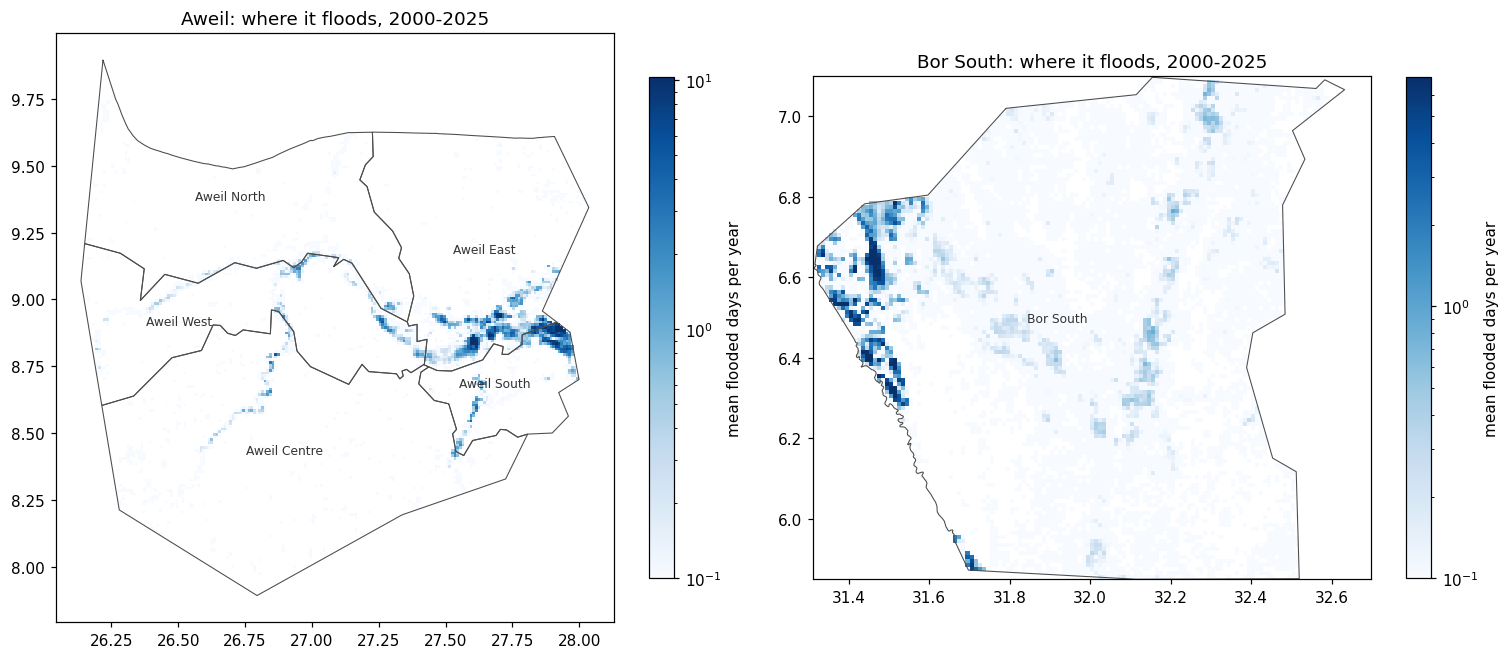

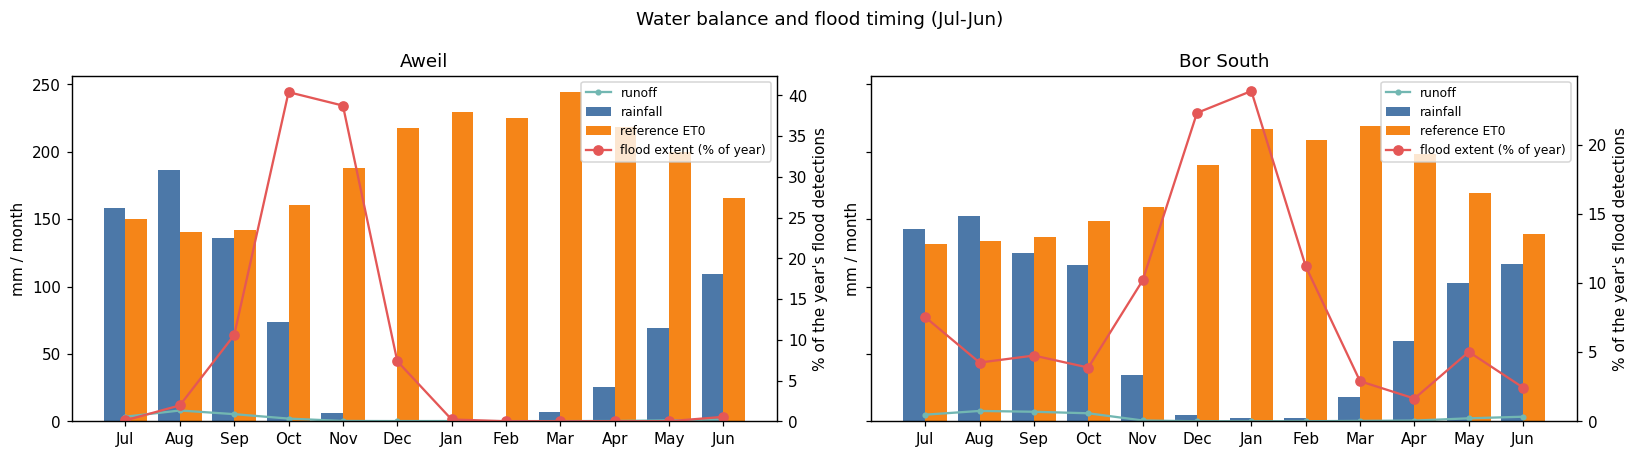

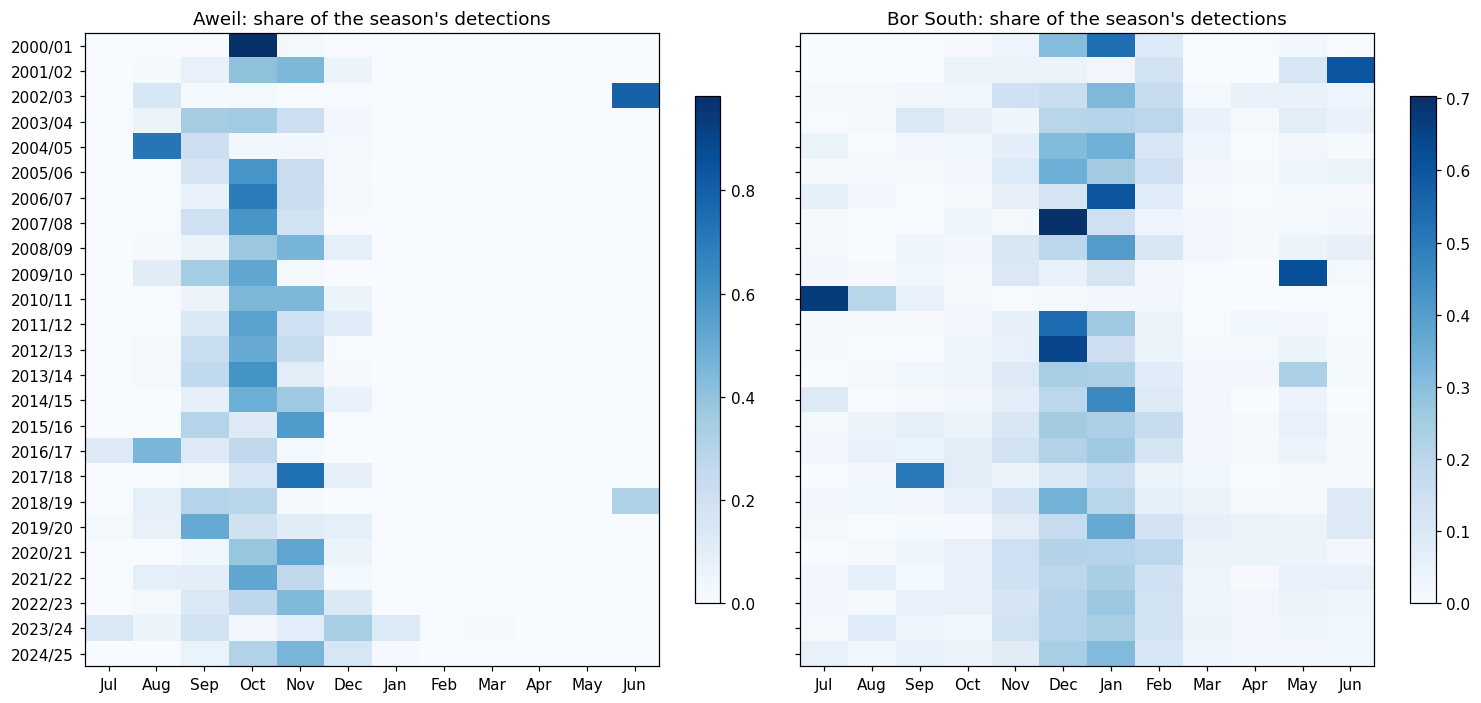

In [2]:
# 3. Focus on Aweil and Bor South: the national exploration repeated for ZOA's two areas
reg = {}
for name, counties in REGIONS.items():
    g = geom(counties)
    rain = region_mean(era.tp, g, 0.25)
    ro = region_mean(era.ro, g, 0.25)
    et0 = region_mean(et_mm, g, 0.1)
    fm = flood_monthly(counties)
    reg[name] = dict(counties=counties, geom=g, rain=rain, runoff=ro, et0=et0, flood=fm,
                     rain_ym=rain.groupby([rain.index.year, rain.index.month]).sum().unstack(),
                     ro_ym=ro.groupby([ro.index.year, ro.index.month]).sum().unstack(),
                     et_ym=et0.groupby([et0.index.year, et0.index.month]).sum().unstack())

# where inside each region it floods (mean flooded days per year, 0.01 deg cells)
cell_km2 = lambda la: (xc.CELL * 111.32) ** 2 * np.cos(np.deg2rad(la))
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, r) in zip(axs, reg.items()):
    f = ssd[ssd.adm2_name.isin(r["counties"])].groupby(["cell_lat", "cell_lon"]).pixeldays.sum().reset_index()
    f["days"] = f.pixeldays * xc.PIXEL_KM2 / cell_km2(f.cell_lat) / len(xc.YEARS)
    gr = f.pivot(index="cell_lat", columns="cell_lon", values="days")
    im = ax.pcolormesh(gr.columns, gr.index, gr.values, cmap="Blues", shading="nearest",
                       norm=mcolors.LogNorm(vmin=0.1, vmax=np.nanpercentile(gr.values, 99.5)))
    a2[a2.adm2_name.isin(r["counties"])].boundary.plot(ax=ax, color="0.3", lw=0.7)
    for _, row in a2[a2.adm2_name.isin(r["counties"])].iterrows():
        p = row.geometry.representative_point()
        ax.annotate(row.adm2_name, (p.x, p.y), fontsize=8, ha="center", color="0.2")
    fig.colorbar(im, ax=ax, label="mean flooded days per year", shrink=0.8)
    ax.set_title(f"{name}: where it floods, 2000-2025"); ax.set_aspect("equal")
fig.tight_layout(); fig.savefig(FIG / "03_region_flood_maps.png", bbox_inches="tight")

# seasonal cycle: rain, ET0, runoff and flood timing (Jul-Jun)
fig, axs = plt.subplots(1, 2, figsize=(15, 4.2), sharey=True)
for ax, (name, r) in zip(axs, reg.items()):
    fm = r["flood"].unstack()
    clim_f = fm.mean().reindex(wy_order) / fm.mean().sum() * 100
    x = np.arange(12)
    ax.bar(x - 0.2, r["rain_ym"].mean().reindex(wy_order), 0.4, label="rainfall", color="#4c78a8")
    ax.bar(x + 0.2, r["et_ym"].mean().reindex(wy_order), 0.4, label="reference ET0", color="#f58518")
    ax.plot(x, r["ro_ym"].mean().reindex(wy_order), color="#72b7b2", marker=".", label="runoff")
    ax2 = ax.twinx(); ax2.plot(x, clim_f, color="#e45756", marker="o", label="flood extent (% of year)")
    ax2.set_ylim(0, None); ax2.set_ylabel("% of the year's flood detections")
    ax.set_xticks(x, wy_labels); ax.set_title(name); ax.set_ylabel("mm / month")
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper right")
fig.suptitle("Water balance and flood timing (Jul-Jun)")
fig.tight_layout(); fig.savefig(FIG / "03_region_water_balance.png", bbox_inches="tight")

# flood season x month, as share of each season's detections
fig, axs = plt.subplots(1, 2, figsize=(14, 6.5), sharey=True)
for ax, (name, r) in zip(axs, reg.items()):
    s = r["flood"].rename("px").reset_index()
    s["wy"] = s.year - (s.month <= 6)
    t = s[s.wy.between(2000, 2024)].pivot_table(index="wy", columns="month", values="px", aggfunc="sum").reindex(columns=wy_order)
    r["season_month"] = t
    im = ax.imshow(t.div(t.sum(axis=1), axis=0).values, aspect="auto", cmap="Blues")
    ax.set_xticks(range(12), wy_labels); ax.set_yticks(range(len(t)), [f"{y}/{str(y + 1)[2:]}" for y in t.index])
    ax.set_title(f"{name}: share of the season's detections"); fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout(); fig.savefig(FIG / "03_region_season_month.png", bbox_inches="tight")

# people in frequently flooded cells (>= 5 of 16 MODIS-only seasons)
pop = xc.population_cells(2020)
freq = ssd[ssd.wy.between(2003, 2018)].groupby(["cell_lat", "cell_lon"]).wy.nunique().rename("seasons").reset_index()
pop_f = pop.merge(freq, on=["cell_lat", "cell_lon"], how="left").fillna({"seasons": 0})

# summary table, one column per region
MF = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2]  # Mar-start order, so both rain and flood peaks sit inside
rows = {}
for name, r in reg.items():
    ann_rain = r["rain_ym"].sum(axis=1)
    tr = stats.linregress(ann_rain.index, ann_rain.values)
    clim_r, clim_f, clim_e = r["rain_ym"].mean(), r["flood"].unstack().mean(), r["et_ym"].mean()
    cen = lambda c: (c.reindex(MF).values * np.arange(12)).sum() / c.sum()
    sea = r["season_month"].sum(axis=1)
    nat_sea = ssd[ssd.wy.between(2000, 2024)].groupby("wy").pixeldays.sum()
    share = (sea / nat_sea).loc[2003:2024]
    rain_dt = detrend(ann_rain.loc[2003:2024]); share_dt = detrend(np.log(share))
    rr = stats.pearsonr(rain_dt, share_dt)
    area = area_km2.loc[r["counties"]].sum()
    pf = pop_f[pop_f.adm2_name.isin(r["counties"])]
    rows[name] = {
        "area (km2)": f"{area:,.0f}",
        "mean annual rain (mm)": f"{ann_rain.mean():.0f}",
        "rain trend (mm/decade)": f"{tr.slope * 10:+.0f} (p={tr.pvalue:.2f})",
        "rain 2000-14 / 2015-25 (mm)": f"{ann_rain.loc[:2014].mean():.0f} / {ann_rain.loc[2015:].mean():.0f}",
        "runoff ratio": f"{r['ro_ym'].sum().sum() / r['rain_ym'].sum().sum():.1%}",
        "months with rain > ET0": ", ".join(months[m - 1] for m in range(1, 13) if clim_r[m] > clim_e[m]) or "none",
        "rain peak month": months[clim_r.idxmax() - 1],
        "flood peak month": months[clim_f.idxmax() - 1],
        "flood lags rain (days)": f"{(cen(clim_f) - cen(clim_r)) * 30.4:.0f}",
        "rain - ET0 in flood peak month (mm)": f"{clim_r[clim_f.idxmax()] - clim_e[clim_f.idxmax()]:+.0f}",
        "flood density 2003-18 (days/yr)": f"{sea.loc[2003:2018].mean() * xc.PIXEL_KM2 / area:.2f}",
        "detections 2021-24 vs 2003-18": f"x{sea.loc[2021:2024].mean() / sea.loc[2003:2018].mean():.1f}",
        "share of national detections": f"{(sea.loc[2003:2024].sum() / nat_sea.loc[2003:2024].sum()):.1%}",
        "people in frequently flooded cells": f"{pf.loc[pf.seasons >= 5, 'pop'].sum():,.0f} of {pf['pop'].sum():,.0f}",
        "detrended r(annual rain, flood share) 2003-24": f"{rr[0]:+.2f} (p={rr[1]:.2f})",
    }
summary3 = pd.DataFrame(rows)
summary3

Do the two areas flood together? (seasons 2003-24, detrended, Spearman)
  flood share Aweil vs Bor South: rho = +0.09 (p = 0.68)
  annual rain Aweil vs Bor South: rho = +0.40 (p = 0.07)
  peak month per season:
        Aweil: {'Oct': 10, 'Nov': 7, 'Aug': 2, 'Jun': 1, 'Sep': 1, 'Dec': 1}
    Bor South: {'Jan': 11, 'Dec': 8, 'May': 1, 'Jul': 1, 'Sep': 1}

Aweil East + South: 87% of Aweil's flood detections, 27% of its area, 79% of its exposed people


,area (km2),share of Aweil detections (%),density 2003-18 (days/yr),peak month,people in frequently flooded cells,population
adm2_name,,,,,,
Aweil South,1976.88,39.07,0.31,Nov,6524.98,123794.969
Aweil East,6367.53,47.68,0.16,Oct,12216.90,292363.875
Aweil West,5007.85,7.80,0.03,Oct,3358.89,172402.516
Aweil Centre,11156.75,3.91,0.01,Oct,926.60,59111.270
Aweil North,6342.81,1.55,0.00,Oct,643.20,144982.719


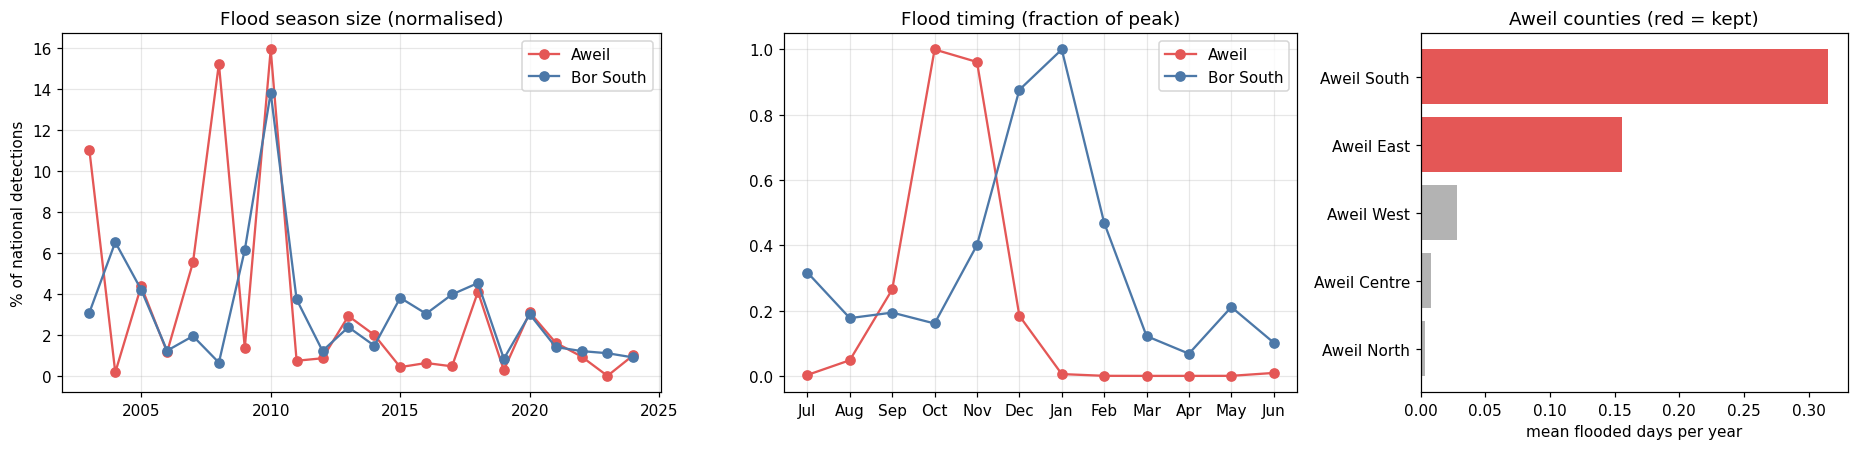

In [3]:
# 4. Separate on Aweil only: evidence that the two areas behave differently, then which Aweil counties to keep
nat_sea = ssd[ssd.wy.between(2000, 2024)].groupby("wy").pixeldays.sum()
share_sea = pd.DataFrame({k: reg[k]["season_month"].sum(axis=1) / nat_sea for k in reg}).loc[2003:2024]
peak = pd.DataFrame({k: reg[k]["season_month"].idxmax(axis=1).map(lambda m: months[m - 1]) for k in reg}).loc[2003:2024]
ann_rain = pd.DataFrame({k: reg[k]["rain_ym"].sum(axis=1) for k in reg}).loc[2003:2024]

r_flood = stats.spearmanr(detrend(np.log(share_sea.Aweil)), detrend(np.log(share_sea["Bor South"])))
r_rain = stats.spearmanr(detrend(ann_rain.Aweil), detrend(ann_rain["Bor South"]))
print("Do the two areas flood together? (seasons 2003-24, detrended, Spearman)")
print(f"  flood share Aweil vs Bor South: rho = {r_flood[0]:+.2f} (p = {r_flood[1]:.2f})")
print(f"  annual rain Aweil vs Bor South: rho = {r_rain[0]:+.2f} (p = {r_rain[1]:.2f})")
print("  peak month per season:")
for k in peak:
    print(f"    {k:>9}: {peak[k].value_counts().to_dict()}")

# within Aweil: which counties actually flood
aw = ssd[ssd.adm2_name.isin(AWEIL_ALL) & ssd.wy.between(2003, 2024)]
cy = aw.groupby(["adm2_name", "wy"]).pixeldays.sum().unstack(fill_value=0).reindex(AWEIL_ALL, fill_value=0)
cm = aw.groupby(["adm2_name", "month"]).pixeldays.sum().unstack(fill_value=0).reindex(columns=wy_order, fill_value=0)
pf = pop_f[pop_f.adm2_name.isin(AWEIL_ALL)]
counties4 = pd.DataFrame({
    "area (km2)": area_km2.loc[AWEIL_ALL],
    "share of Aweil detections (%)": cy.sum(axis=1) / cy.values.sum() * 100,
    "density 2003-18 (days/yr)": cy.loc[:, 2003:2018].mean(axis=1) * xc.PIXEL_KM2 / area_km2.loc[AWEIL_ALL],
    "peak month": cm.idxmax(axis=1).map(lambda m: months[m - 1]),
    "people in frequently flooded cells": pf[pf.seasons >= 5].groupby("adm2_name")["pop"].sum().reindex(AWEIL_ALL, fill_value=0),
    "population": pf.groupby("adm2_name")["pop"].sum().reindex(AWEIL_ALL),
}).sort_values("density 2003-18 (days/yr)", ascending=False)
core = counties4.loc[AWEIL_CORE]
print(f"\nAweil East + South: {core['share of Aweil detections (%)'].sum():.0f}% of Aweil's flood detections, "
      f"{core['area (km2)'].sum() / counties4['area (km2)'].sum():.0%} of its area, "
      f"{core['people in frequently flooded cells'].sum() / counties4['people in frequently flooded cells'].sum():.0%} of its exposed people")
display(counties4.round(2))

fig, axs = plt.subplots(1, 3, figsize=(17, 4.2), gridspec_kw={"width_ratios": [1.4, 1.2, 1]})
for k, col in zip(share_sea, ["#e45756", "#4c78a8"]):
    axs[0].plot(share_sea.index, share_sea[k] * 100, marker="o", label=k, color=col)
axs[0].set_ylabel("% of national detections"); axs[0].set_title("Flood season size (normalised)"); axs[0].legend(); axs[0].grid(alpha=0.3)
for k, col in zip(reg, ["#e45756", "#4c78a8"]):
    c = reg[k]["season_month"].loc[2003:2024].sum()
    axs[1].plot(range(12), c / c.max(), marker="o", label=k, color=col)
axs[1].set_xticks(range(12), wy_labels); axs[1].set_title("Flood timing (fraction of peak)"); axs[1].legend(); axs[1].grid(alpha=0.3)
d = counties4["density 2003-18 (days/yr)"]
axs[2].barh(d.index, d.values, color=["#e45756" if c in AWEIL_CORE else "0.7" for c in d.index])
axs[2].invert_yaxis(); axs[2].set_xlabel("mean flooded days per year"); axs[2].set_title("Aweil counties (red = kept)")
fig.tight_layout(); fig.savefig(FIG / "04_split_evidence.png", bbox_inches="tight")

ERA5 cells touching Aweil East+South: 19;  annual rain r with all five Aweil counties = 0.98
annual rain 730 mm (CV 0.18); trend -144 mm/decade (p=0.000)
Jun-Aug rain 445 mm = 61% of the year; trend -77 mm/decade (p=0.000)
mean onset: day 158 (06 Jun), sd 27 days
monthly climatology (mm), rain and ET0:
              Jan    Feb    Mar    Apr    May    Jun    Jul    Aug    Sep    Oct    Nov    Dec
rain          0.0    0.0    6.0   22.0   61.0  100.0  159.0  187.0  123.0   68.0    5.0    0.0
ET0         236.0  231.0  251.0  223.0  206.0  170.0  151.0  141.0  143.0  162.0  191.0  223.0
rain - ET0 -236.0 -231.0 -245.0 -202.0 -145.0  -70.0    7.0   46.0  -20.0  -94.0 -186.0 -223.0


,annual,May-Aug,Jun-Aug,Jul-Aug,Jul-Sep (after 31 Aug),max 5-day Jun-Aug,days >= 10 mm Jun-Aug,onset (day of year),JJA anom vs trend,JJA anom vs prev 10y
2000,898.6,665.4,581.6,430.8,554.1,52.4,20,114,39.5,NaN
2001,939.1,688.5,594.8,487.4,631.2,165.9,14,134,60.3,NaN
2002,729.0,470.5,424.8,297.1,410.4,41.6,9,154,-101.9,NaN
2003,952.0,689.2,607.8,453.3,613.6,58.6,22,151,88.9,74.1
2004,804.5,529.3,451.6,322.4,448.4,50.6,14,143,-59.6,-100.6
2005,908.4,627.3,513.6,358.9,490.7,45.2,16,123,10.2,-18.5
2006,913.2,639.9,537.9,394.6,531.9,70.6,19,131,42.2,8.9
2007,827.1,614.8,554.6,431.2,532.6,101.7,16,165,66.6,24.3
2008,765.7,537.3,476.0,384.9,481.5,60.7,14,116,-4.1,-57.3
2009,728.2,472.2,445.2,333.9,460.9,56.2,14,179,-27.2,-81.8


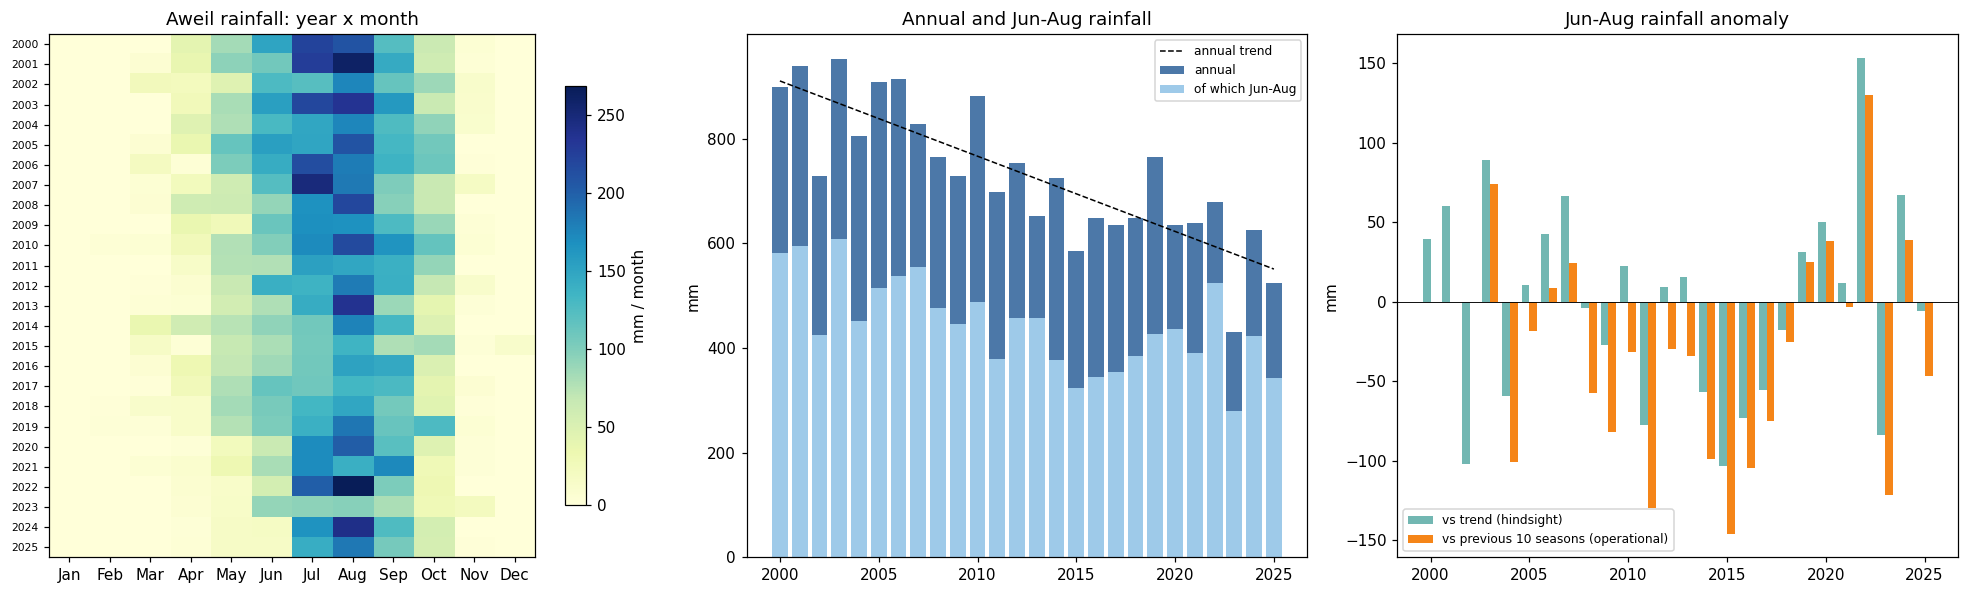

In [4]:
# 5. Rain data on Aweil (Aweil East + South), with the features that are known by the 31 Aug decision date
g_aw = geom(AWEIL_CORE)
rain = region_mean(era.tp, g_aw, 0.25)
rain_ym = rain.groupby([rain.index.year, rain.index.month]).sum().unstack()
et_aw = region_mean(et_mm, g_aw, 0.1)
et_ym = et_aw.groupby([et_aw.index.year, et_aw.index.month]).sum().unstack()
r_all = stats.pearsonr(rain_ym.sum(axis=1), reg["Aweil"]["rain_ym"].sum(axis=1))[0]
print(f"ERA5 cells touching Aweil East+South: {(grid_weights(era.tp, g_aw, 0.25) > 0).sum()};  "
      f"annual rain r with all five Aweil counties = {r_all:.2f}")


def onset_doy(d, thresh=20, dry=10):
    """First day from 1 Apr with a 3-day total >= thresh mm, not followed by a >= dry-day dry spell (<1 mm) in 30 days."""
    d = d.loc[f"{d.index.year[0]}-04-01":]
    wet3 = d.rolling(3).sum()
    for t in wet3.index[wet3 >= thresh]:
        nxt = (d.loc[t:t + pd.Timedelta(days=30)] < 1).astype(int)
        if nxt.groupby((nxt == 0).cumsum()).sum().max() < dry:
            return t.dayofyear
    return np.nan


feat = pd.DataFrame({
    "annual": rain_ym.sum(axis=1),
    "May-Aug": rain_ym.loc[:, 5:8].sum(axis=1),
    "Jun-Aug": rain_ym.loc[:, 6:8].sum(axis=1),
    "Jul-Aug": rain_ym.loc[:, 7:8].sum(axis=1),
    "Jul-Sep (after 31 Aug)": rain_ym.loc[:, 7:9].sum(axis=1),
})
jja = rain[rain.index.month.isin([6, 7, 8])]
feat["max 5-day Jun-Aug"] = jja.rolling(5).sum().groupby(jja.index.year).max()
feat["days >= 10 mm Jun-Aug"] = (jja >= 10).groupby(jja.index.year).sum()
feat["onset (day of year)"] = rain.groupby(rain.index.year).apply(onset_doy)
# two anomaly definitions for Jun-Aug rain: vs the full-sample trend (hindsight), and vs the
# mean of the previous up-to-10 seasons (known at decision time, so usable operationally)
feat["JJA anom vs trend"] = detrend(feat["Jun-Aug"])
feat["JJA anom vs prev 10y"] = feat["Jun-Aug"] - feat["Jun-Aug"].shift(1).rolling(10, min_periods=3).mean()

tr = stats.linregress(feat.index, feat.annual)
trj = stats.linregress(feat.index, feat["Jun-Aug"])
print(f"annual rain {feat.annual.mean():.0f} mm (CV {feat.annual.std() / feat.annual.mean():.2f}); "
      f"trend {tr.slope * 10:+.0f} mm/decade (p={tr.pvalue:.3f})")
print(f"Jun-Aug rain {feat['Jun-Aug'].mean():.0f} mm = {feat['Jun-Aug'].sum() / feat.annual.sum():.0%} of the year; "
      f"trend {trj.slope * 10:+.0f} mm/decade (p={trj.pvalue:.3f})")
print(f"mean onset: day {feat['onset (day of year)'].mean():.0f} "
      f"({(pd.Timestamp('2001-01-01') + pd.Timedelta(days=feat['onset (day of year)'].mean() - 1)):%d %b}), "
      f"sd {feat['onset (day of year)'].std():.0f} days")
print("monthly climatology (mm), rain and ET0:")
print(pd.DataFrame({"rain": rain_ym.mean(), "ET0": et_ym.mean(), "rain - ET0": rain_ym.mean() - et_ym.mean()})
        .rename(index=dict(enumerate(months, 1))).round(0).T.to_string())

fig, axs = plt.subplots(1, 3, figsize=(18, 5.5), gridspec_kw={"width_ratios": [1.3, 1.2, 1.2]})
im = axs[0].imshow(rain_ym.values, aspect="auto", cmap="YlGnBu")
axs[0].set_xticks(range(12), months); axs[0].set_yticks(range(len(rain_ym)), rain_ym.index, fontsize=7)
fig.colorbar(im, ax=axs[0], label="mm / month", shrink=0.8); axs[0].set_title("Aweil rainfall: year x month")
axs[1].bar(feat.index, feat.annual, color="#4c78a8", label="annual")
axs[1].bar(feat.index, feat["Jun-Aug"], color="#9ecae9", label="of which Jun-Aug")
axs[1].plot(feat.index, np.polyval(np.polyfit(feat.index, feat.annual, 1), feat.index), "k--", lw=1, label="annual trend")
axs[1].set_ylabel("mm"); axs[1].legend(fontsize=8); axs[1].set_title("Annual and Jun-Aug rainfall")
w = 0.4
axs[2].bar(feat.index - w / 2, feat["JJA anom vs trend"], w, label="vs trend (hindsight)", color="#72b7b2")
axs[2].bar(feat.index + w / 2, feat["JJA anom vs prev 10y"], w, label="vs previous 10 seasons (operational)", color="#f58518")
axs[2].axhline(0, color="k", lw=0.6); axs[2].legend(fontsize=8); axs[2].set_ylabel("mm"); axs[2].set_title("Jun-Aug rainfall anomaly")
fig.tight_layout(); fig.savefig(FIG / "05_aweil_rain.png", bbox_inches="tight")
feat.round(1)

mean share of the season's detections per month (%), 2003-24:
month
Jul     1.6
Aug     6.7
Sep    18.0
Oct    37.8
Nov    28.4
Dec     6.3
Jan     0.7
Feb     0.0
Mar     0.0
Apr     0.0
May     0.0
Jun     0.5
share in Sep-Dec (the target window): 90%;  already in Jul-Aug: 8%
peak month per season: {'Oct': 12, 'Nov': 6, 'Sep': 2, 'Aug': 1, 'Dec': 1}

rank agreement of severity with a whole-season national denominator: rho = 0.98
Aweil Sep-Dec detections: 2000-02 mean 1,548 vs 2003-18 29,509 pixel-days -> 2000-02 left out of every test

severe seasons (detrended, used from here on): [2003, 2008, 2010, 2014, 2018, 2020, 2021, 2024]
severe seasons if the raw share were used:      [2003, 2005, 2007, 2008, 2010, 2013, 2014, 2020]
top third by raw km2-days:                       [2007, 2008, 2010, 2014, 2020, 2021, 2022, 2024]


,aweil_px,national_px,km2_days,share,log_share,peak month,persistence,low coverage,sev_dt,severe
year,,,,,,,,,,
2000,33,8082,1.775,0.004,-5.501,Oct,0.000,True,NaN,NaN
2001,4551,14046,244.777,0.324,-1.127,Nov,0.000,True,NaN,NaN
2002,61,97943,3.281,0.001,-7.381,Jun,0.811,True,NaN,NaN
2003,27583,168721,1483.561,0.163,-1.811,Oct,0.000,False,1.091,1.0
2004,86,71387,4.626,0.001,-6.722,Aug,0.000,False,-3.730,0.0
2005,14405,204080,774.778,0.071,-2.651,Oct,0.000,False,0.429,0.0
2006,11954,561549,642.950,0.021,-3.850,Oct,0.002,False,-0.680,0.0
2007,34453,506740,1853.066,0.068,-2.688,Oct,0.000,False,0.570,0.0
2008,231691,896178,12461.579,0.259,-1.353,Nov,0.003,False,1.995,1.0


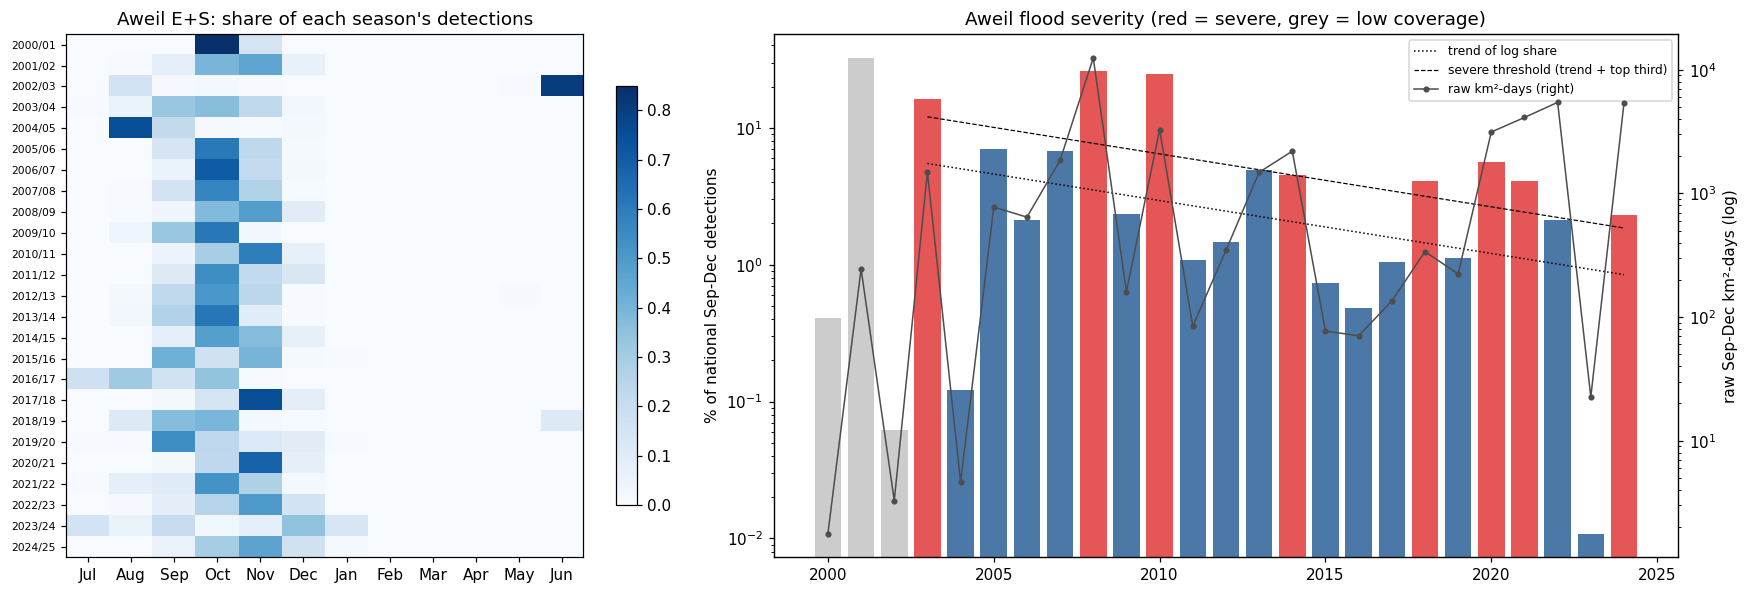

In [5]:
# 6. Flood data on Aweil (Aweil East + South): timing, a normalised severity index and a "severe" definition
fm = flood_monthly(AWEIL_CORE).unstack()
s = flood_monthly(AWEIL_CORE).rename("px").reset_index(); s["wy"] = s.year - (s.month <= 6)
sm_ = s[s.wy.between(2000, 2024)].pivot_table(index="wy", columns="month", values="px", aggfunc="sum").reindex(columns=wy_order)
sm_share = sm_.div(sm_.sum(axis=1), axis=0)
clim = sm_share.loc[2003:2024].mean()
TARGET = [9, 10, 11, 12]  # flooding after the 31 Aug decision date
print("mean share of the season's detections per month (%), 2003-24:")
print((clim * 100).round(1).rename(dict(enumerate(months, 1))).to_string())
print(f"share in Sep-Dec (the target window): {clim.loc[TARGET].sum():.0%};  already in Jul-Aug: {clim.loc[[7, 8]].sum():.0%}")
print("peak month per season:", sm_share.loc[2003:2024].idxmax(axis=1).map(lambda m: months[m - 1]).value_counts().to_dict())

# severity: Aweil's Sep-Dec detections as a share of South Sudan's Sep-Dec detections. Dividing by the
# national total over the same months removes the sensor/detection-volume jump (2019+) and cloud effects.
fl = pd.DataFrame({
    "aweil_px": fm.loc[:, TARGET].sum(axis=1),
    "national_px": nat_m.unstack().loc[:, TARGET].sum(axis=1),
}).loc[2000:2024]
fl["km2_days"] = fl.aweil_px * xc.PIXEL_KM2
fl["share"] = fl.aweil_px / fl.national_px
fl["log_share"] = np.log(fl.share)
fl["peak month"] = sm_.idxmax(axis=1).map(lambda m: months[m - 1])
fl["persistence"] = sm_.loc[:, [1, 2, 3, 4, 5, 6]].sum(axis=1) / sm_.sum(axis=1)  # share left in Jan-Jun
fl["low coverage"] = fl.index <= 2002

# robustness of the normalisation: alternative denominator = the whole national flood season (Jul-Jun)
alt = fl.aweil_px / nat_sea
print(f"\nrank agreement of severity with a whole-season national denominator: "
      f"rho = {stats.spearmanr(fl.share.loc[2003:2024], alt.loc[2003:2024])[0]:.2f}")
print(f"Aweil Sep-Dec detections: 2000-02 mean {fl.aweil_px.loc[:2002].mean():,.0f} vs 2003-18 {fl.aweil_px.loc[2003:2018].mean():,.0f} "
      f"pixel-days -> 2000-02 left out of every test")

# 'severe' = top third of the DETRENDED log share over 2003-24, fixed before any rain is looked at.
# Why detrended: Aweil's raw Sep-Dec detections grew x2.3 while the national total grew ~x14 (Sudd + sensor),
# so the raw share drifts down and would label every recent season 'normal' (2021, 2022, 2024 are among
# Aweil's largest raw floods). Detrending keeps the volume normalisation but removes that drift.
EVAL = slice(2003, 2024)
fl["sev_dt"] = np.nan
fl.loc[EVAL, "sev_dt"] = detrend(fl.loc[EVAL, "log_share"])
thr = fl.loc[EVAL, "sev_dt"].quantile(2 / 3)
fl["severe"] = np.where(fl.sev_dt.notna(), (fl.sev_dt >= thr).astype(float), np.nan)
raw_severe = fl.loc[EVAL, "share"] >= fl.loc[EVAL, "share"].quantile(2 / 3)
print(f"\nsevere seasons (detrended, used from here on): {fl.index[fl.severe == 1].tolist()}")
print(f"severe seasons if the raw share were used:      {raw_severe.index[raw_severe].tolist()}")
print(f"top third by raw km2-days:                       "
      f"{fl.loc[EVAL].index[fl.loc[EVAL, 'km2_days'] >= fl.loc[EVAL, 'km2_days'].quantile(2 / 3)].tolist()}")

fig, axs = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1, 1.4]})
im = axs[0].imshow(sm_share.values, aspect="auto", cmap="Blues")
axs[0].set_xticks(range(12), wy_labels); axs[0].set_yticks(range(len(sm_share)), [f"{y}/{str(y + 1)[2:]}" for y in sm_share.index], fontsize=7)
axs[0].set_title("Aweil E+S: share of each season's detections"); fig.colorbar(im, ax=axs[0], shrink=0.8)
cols = np.where(fl.severe == 1, "#e45756", np.where(fl["low coverage"], "0.8", "#4c78a8"))
axs[1].bar(fl.index, fl.share * 100, color=cols)
axs[1].set_yscale("log")
tl = np.exp(np.polyval(np.polyfit(fl.loc[EVAL].index, fl.loc[EVAL, "log_share"], 1), fl.loc[EVAL].index))
axs[1].plot(fl.loc[EVAL].index, tl * 100, "k:", lw=1, label="trend of log share")
axs[1].plot(fl.loc[EVAL].index, tl * np.exp(thr) * 100, "k--", lw=0.8, label="severe threshold (trend + top third)")
ax2 = axs[1].twinx(); ax2.plot(fl.index, fl.km2_days, color="0.3", marker=".", lw=1, label="raw km²-days (right)")
ax2.set_yscale("log"); ax2.set_ylabel("raw Sep-Dec km²-days (log)")
axs[1].set_ylabel("% of national Sep-Dec detections"); axs[1].set_title("Aweil flood severity (red = severe, grey = low coverage)")
h1, l1 = axs[1].get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); axs[1].legend(h1 + h2, l1 + l2, fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "06_aweil_flood.png", bbox_inches="tight")
fl.round(3)

detrended r                              detrended p                             
seasons                    2000-24 2003-18 (MODIS only) 2003-24     2000-24 2003-18 (MODIS only) 2003-24
rain feature                                                                                            
annual                        0.65                 0.53    0.57        0.00                 0.04    0.01
May-Aug                       0.65                 0.62    0.60        0.00                 0.01    0.00
Jun-Aug                       0.58                 0.68    0.57        0.00                 0.00    0.01
Jul-Aug                       0.61                 0.77    0.62        0.00                 0.00    0.00
Jul-Sep (after 31 Aug)        0.66                 0.69    0.65        0.00                 0.00    0.00
max 5-day Jun-Aug             0.44                 0.40    0.37        0.03                 0.13    0.09
days >= 10 mm Jun-Aug         0.47                 0.54    0.50        0.02                 0.03    0.02
onset (day of year)          -0.14                 0.00   -0.10        0.52                 1.00    0.65

rain anomaly (May-Sep months) vs flood-share anomaly L months later, Spearman: {'lag 0': np.float64(0.1), 'lag 1': np.float64(0.16), 'lag 2': np.float64(0.24), 'lag 3': np.float64(0.33), 'lag 4': np.float64(0.46)}


,4,5,6,7,8,9,10,11
rho,0.08,-0.13,-0.29,0.49,0.6,0.24,-0.28,-0.15
p,0.74,0.55,0.19,0.02,0.0,0.29,0.20,0.52


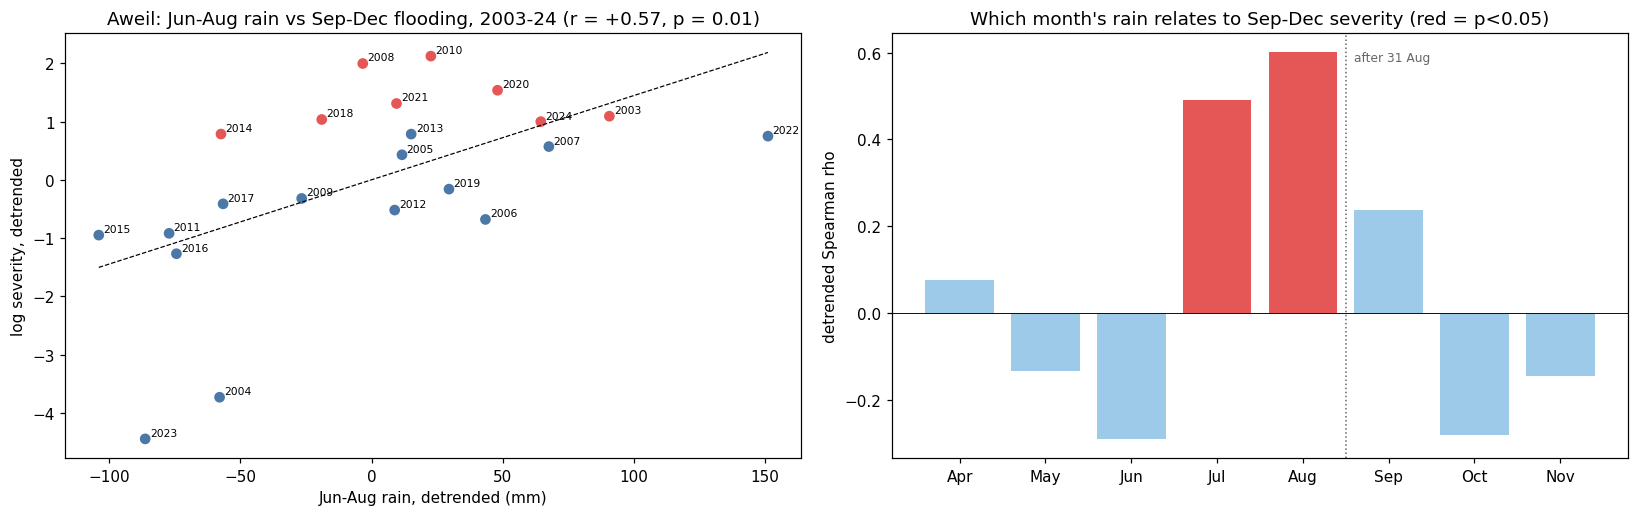

In [6]:
# 7. Correlation between Aweil rain and Aweil flood severity (Sep-Dec share), raw and detrended
df = feat.join(fl[["share", "log_share", "severe"]], how="inner")
FEATS = ["annual", "May-Aug", "Jun-Aug", "Jul-Aug", "Jul-Sep (after 31 Aug)", "max 5-day Jun-Aug",
         "days >= 10 mm Jun-Aug", "onset (day of year)"]
PERIODS = {"2000-24": (2000, 2024), "2003-24": (2003, 2024), "2003-18 (MODIS only)": (2003, 2018)}
rows = []
for x in FEATS:
    for lab, (a, b) in PERIODS.items():
        d = df.loc[a:b, [x, "log_share"]].dropna()
        xr_, yr_ = detrend(d[x]), detrend(d.log_share)
        rows.append({"rain feature": x, "seasons": lab, "n": len(d),
                     "raw r": stats.pearsonr(d[x], d.log_share)[0],
                     "detrended r": stats.pearsonr(xr_, yr_)[0], "detrended p": stats.pearsonr(xr_, yr_)[1],
                     "detrended rho": stats.spearmanr(xr_, yr_)[0], "rho p": stats.spearmanr(xr_, yr_)[1]})
corr7 = pd.DataFrame(rows)
display(corr7.pivot(index="rain feature", columns="seasons", values=["detrended r", "detrended p"]).reindex(FEATS).round(2))

# which month's rain matters? detrended Spearman of each month's rain with the Sep-Dec severity, 2003-24
d = rain_ym.loc[2003:2024].join(df.log_share)
mon = pd.DataFrame({m: stats.spearmanr(detrend(d[m]), detrend(d.log_share)) for m in range(4, 12)}, index=["rho", "p"]).T

# monthly anomalies, lagged: rain anomaly in month t vs flood-share anomaly in month t+L (2003-24, Jun-Dec)
fl_m = (fm / nat_m.unstack().replace(0, np.nan)).loc[2003:2024]
fa = (np.log(fl_m + 1e-4) - np.log(fl_m + 1e-4).mean()).stack()
ra = (rain_ym.loc[2003:2024] - rain_ym.loc[2003:2024].mean()).stack()
lag = {}
for L in range(0, 5):
    pairs = [(ra[(y, m)], fa.get((y, m + L), np.nan)) for y in range(2003, 2025) for m in range(5, 10) if m + L <= 12]
    p = pd.DataFrame(pairs).dropna()
    lag[L] = stats.spearmanr(p[0], p[1])[0]
print("rain anomaly (May-Sep months) vs flood-share anomaly L months later, Spearman:",
      {f"lag {k}": round(v, 2) for k, v in lag.items()})

fig, axs = plt.subplots(1, 2, figsize=(15, 4.8))
x_ = detrend(df.loc[2003:2024, "Jun-Aug"]); y_ = detrend(df.loc[2003:2024, "log_share"])
axs[0].scatter(x_, y_, c=np.where(df.loc[2003:2024, "severe"] == 1, "#e45756", "#4c78a8"))
for yr in x_.index:
    axs[0].annotate(yr, (x_[yr], y_[yr]), fontsize=7, xytext=(3, 2), textcoords="offset points")
axs[0].plot(np.sort(x_), np.polyval(np.polyfit(x_, y_, 1), np.sort(x_)), "k--", lw=0.8)
rr = stats.pearsonr(x_, y_)
axs[0].set_xlabel("Jun-Aug rain, detrended (mm)"); axs[0].set_ylabel("log severity, detrended")
axs[0].set_title(f"Aweil: Jun-Aug rain vs Sep-Dec flooding, 2003-24 (r = {rr[0]:+.2f}, p = {rr[1]:.2f})")
axs[1].bar([months[m - 1] for m in mon.index], mon.rho, color=np.where(mon.p < 0.05, "#e45756", "#9ecae9"))
axs[1].axhline(0, color="k", lw=0.6); axs[1].axvline(4.5, color="0.4", ls=":", lw=1)
axs[1].text(4.6, axs[1].get_ylim()[1] * 0.9, "after 31 Aug", fontsize=8, color="0.4")
axs[1].set_ylabel("detrended Spearman rho"); axs[1].set_title("Which month's rain relates to Sep-Dec severity (red = p<0.05)")
fig.tight_layout(); fig.savefig(FIG / "07_aweil_rain_flood_corr.png", bbox_inches="tight")
mon.round(2).T

Seasons by Jun-Aug rain class (operational anomaly) and outcome:


severe,normal,severe,All
class (operational),,,
dry,7,1,8
normal,3,4,7
wet,4,3,7
All,14,8,22


,hits,misses,false alarms,correct no,hit rate,false alarm ratio,accuracy,Heidke skill,Fisher p
wet tercile -> severe (operational),3.0,5.0,4.0,10.0,0.38,0.57,0.59,0.09,0.51
above baseline -> severe (operational),3.0,5.0,4.0,10.0,0.38,0.57,0.59,0.09,0.51
wet tercile -> severe (hindsight),3.0,5.0,4.0,10.0,0.38,0.57,0.59,0.09,0.51
above baseline -> severe (hindsight),5.0,3.0,7.0,7.0,0.62,0.58,0.55,0.11,0.45
baseline: always normal,0.0,8.0,0.0,14.0,0.00,NaN,0.64,0.00,1.00
baseline: last season severe,1.0,7.0,6.0,8.0,0.12,0.86,0.41,-0.31,0.98


base rate of severe: 36% (8 of 22 seasons)
P(severe | dry Jun-Aug) = 12% (n=8);  P(severe | normal or wet) = 50% (n=14);  Fisher p = 0.17


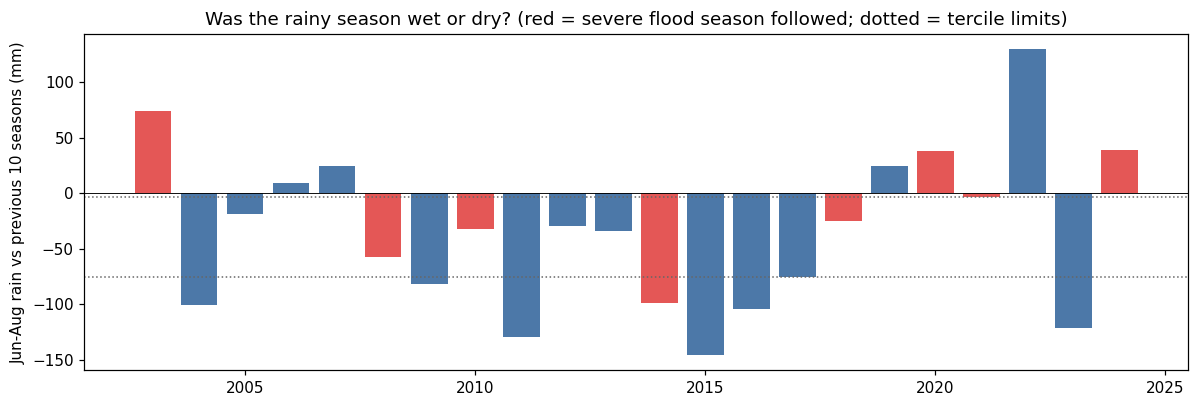

In [7]:
# 8. Wet/dry rainy season (known on 31 Aug) predicting a severe/normal flood season, 2003-24
d8 = df.loc[2003:2024].copy()
d8["severe"] = d8.severe.astype(int)
d8["prev severe"] = fl.severe.shift(1).loc[2003:2024]  # NaN for 2003: 2002 has no trusted label


def scores(pred, obs):
    """Contingency-table scores for a yes/no warning."""
    h = int(((pred == 1) & (obs == 1)).sum()); m = int(((pred == 0) & (obs == 1)).sum())
    fa = int(((pred == 1) & (obs == 0)).sum()); cn = int(((pred == 0) & (obs == 0)).sum())
    n = h + m + fa + cn
    exp = ((h + m) * (h + fa) + (cn + m) * (cn + fa)) / n
    return {"hits": h, "misses": m, "false alarms": fa, "correct no": cn,
            "hit rate": h / (h + m) if h + m else np.nan,
            "false alarm ratio": fa / (h + fa) if h + fa else np.nan,
            "accuracy": (h + cn) / n, "Heidke skill": ((h + cn) - exp) / (n - exp),
            "Fisher p": stats.fisher_exact([[h, fa], [m, cn]], alternative="greater")[1]}


rules = {}
for col, lab in [("JJA anom vs prev 10y", "operational"), ("JJA anom vs trend", "hindsight")]:
    terc = d8[col].quantile([1 / 3, 2 / 3])
    d8[f"class ({lab})"] = pd.cut(d8[col], [-np.inf, *terc, np.inf], labels=["dry", "normal", "wet"])
    rules[f"wet tercile -> severe ({lab})"] = (d8[f"class ({lab})"] == "wet").astype(int)
    rules[f"above baseline -> severe ({lab})"] = (d8[col] > 0).astype(int)
rules["baseline: always normal"] = pd.Series(0, index=d8.index)
rules["baseline: last season severe"] = d8["prev severe"].fillna(0).astype(int)

print("Seasons by Jun-Aug rain class (operational anomaly) and outcome:")
display(pd.crosstab(d8["class (operational)"], d8.severe.map({0: "normal", 1: "severe"}), margins=True))
res8 = pd.DataFrame({k: scores(v, d8.severe) for k, v in rules.items()}).T
display(res8.round(2))
print(f"base rate of severe: {d8.severe.mean():.0%} ({d8.severe.sum()} of {len(d8)} seasons)")
dry = d8["class (operational)"] == "dry"
print(f"P(severe | dry Jun-Aug) = {d8.severe[dry].mean():.0%} (n={dry.sum()});  "
      f"P(severe | normal or wet) = {d8.severe[~dry].mean():.0%} (n={(~dry).sum()});  "
      f"Fisher p = {stats.fisher_exact(pd.crosstab(dry, d8.severe))[1]:.2f}")

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(d8.index, d8["JJA anom vs prev 10y"], color=np.where(d8.severe == 1, "#e45756", "#4c78a8"))
for q in d8["JJA anom vs prev 10y"].quantile([1 / 3, 2 / 3]):
    ax.axhline(q, color="0.4", ls=":", lw=1)
ax.axhline(0, color="k", lw=0.6)
ax.set_ylabel("Jun-Aug rain vs previous 10 seasons (mm)")
ax.set_title("Was the rainy season wet or dry? (red = severe flood season followed; dotted = tercile limits)")
fig.tight_layout(); fig.savefig(FIG / "08_wet_dry_vs_severe.png", bbox_inches="tight")

seasons 2004-2024 (n = 21, 7 severe)
Jun-Aug rain vs trend: LOO AUC = 0.16, permutation p = 0.508 (null AUC median 0.16: leave-one-out AUC is biased low at this n)


,Brier,Brier skill vs climatology,LOO AUC,accuracy (p >= base rate)
climatology (baseline),0.245,0.000,0.500,NaN
Jun-Aug rain vs trend,0.270,-0.103,0.163,0.286
Jul-Aug rain vs trend,0.266,-0.086,0.408,0.571
Jun-Aug rain vs prev 10 seasons,0.262,-0.071,0.367,0.429
Jun-Aug vs trend + max 5-day,0.272,-0.111,0.357,0.381
last season severe (baseline),0.241,0.018,0.367,0.571


odds ratio per +1 SD (62 mm) of detrended Jun-Aug rain: 1.31 (95% CI 0.51-3.34, p = 0.578)


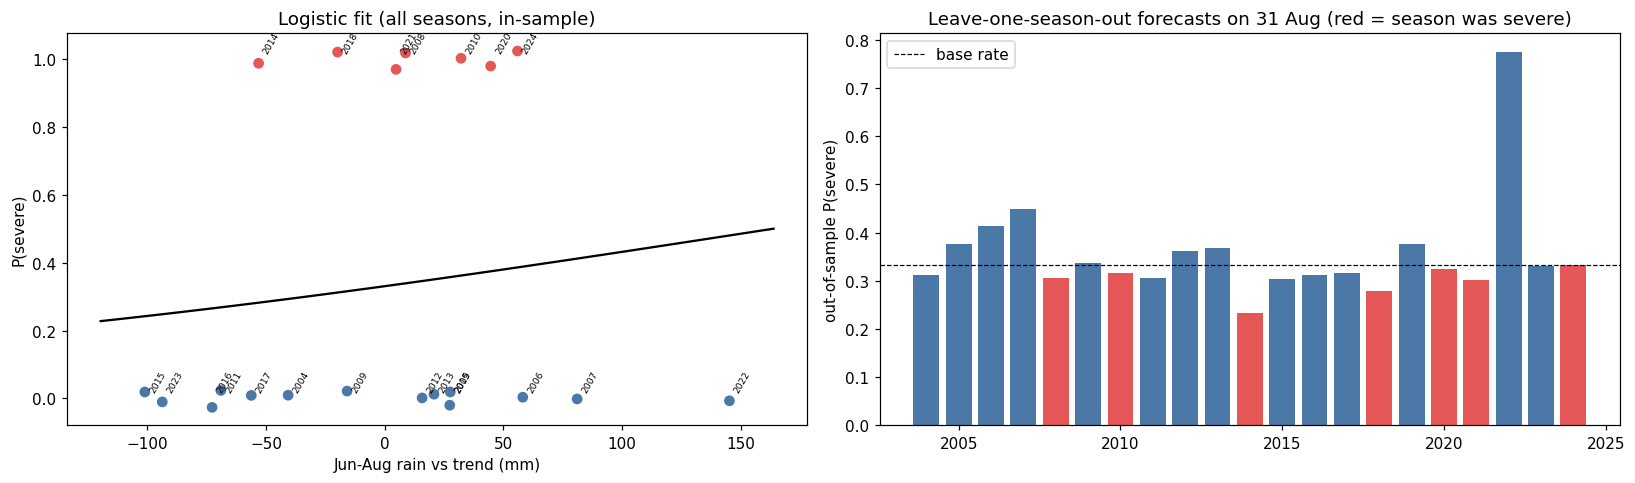

In [8]:
# 9. Logistic regression: P(severe Sep-Dec flood season | rain known on 31 Aug), leave-one-season-out CV
d9 = d8.dropna(subset=["prev severe"]).copy()
y = d9.severe.values
yrs = d9.index.values.astype(float)
# each feature: (column, detrend inside the fold?). Rain trends are fitted on the training seasons only.
MODELS = {
    "Jun-Aug rain vs trend": [("Jun-Aug", True)],
    "Jul-Aug rain vs trend": [("Jul-Aug", True)],
    "Jun-Aug rain vs prev 10 seasons": [("JJA anom vs prev 10y", False)],
    "Jun-Aug vs trend + max 5-day": [("Jun-Aug", True), ("max 5-day Jun-Aug", True)],
    "last season severe (baseline)": [("prev severe", False)],
}


def design(spec, tr):
    """Feature matrix with in-fold detrending and standardisation (both fitted on rows tr only)."""
    cols = []
    for c, dt in spec:
        x = d9[c].values.astype(float)
        if dt:
            x = x - np.polyval(np.polyfit(yrs[tr], x[tr], 1), yrs)
        cols.append(x)
    X = np.column_stack(cols)
    return (X - X[tr].mean(0)) / X[tr].std(0)


def loo_probs(spec, yy=y):
    p = np.empty(len(yy))
    for i in range(len(yy)):
        tr = np.arange(len(yy)) != i
        X = design(spec, tr)
        p[i] = LogisticRegression(C=1.0).fit(X[tr], yy[tr]).predict_proba(X[i:i + 1])[0, 1]  # mild L2: n is small
    return p


clim_p = np.array([y[np.arange(len(y)) != i].mean() for i in range(len(y))])  # climatology baseline
bs_clim = brier_score_loss(y, clim_p)
probs = {"climatology (baseline)": clim_p} | {k: loo_probs(v) for k, v in MODELS.items()}
res9 = pd.DataFrame({k: {"Brier": brier_score_loss(y, p),
                         "Brier skill vs climatology": 1 - brier_score_loss(y, p) / bs_clim,
                         "LOO AUC": 0.5 if k.startswith("climatology") else roc_auc_score(y, p),
                         "accuracy (p >= base rate)": np.nan if k.startswith("climatology") else ((p >= y.mean()) == y).mean()}
                     for k, p in probs.items()}).T

# permutation test on the whole LOO pipeline (labels shuffled), for the pre-registered Jun-Aug model
rng = np.random.default_rng(0)
main = "Jun-Aug rain vs trend"
auc_obs, bss_obs = res9.loc[main, "LOO AUC"], res9.loc[main, "Brier skill vs climatology"]
null = np.array([roc_auc_score(yp, loo_probs(MODELS[main], yp)) for yp in (rng.permutation(y) for _ in range(300))])
print(f"seasons {d9.index.min()}-{d9.index.max()} (n = {len(y)}, {int(y.sum())} severe)")
print(f"{main}: LOO AUC = {auc_obs:.2f}, permutation p = {(np.sum(null >= auc_obs) + 1) / (len(null) + 1):.3f} "
      f"(null AUC median {np.median(null):.2f}: leave-one-out AUC is biased low at this n)")
display(res9.round(3))

# full-sample fit for interpretation (statsmodels: coefficient with CI)
xa = detrend(d9["Jun-Aug"])
z = xa / xa.std()
logit = sm.Logit(y, sm.add_constant(z.values)).fit(disp=0)
b, ci = logit.params[1], logit.conf_int()[1]
print(f"odds ratio per +1 SD ({xa.std():.0f} mm) of detrended Jun-Aug rain: {np.exp(b):.2f} "
      f"(95% CI {np.exp(ci[0]):.2f}-{np.exp(ci[1]):.2f}, p = {logit.pvalues[1]:.3f})")

fig, axs = plt.subplots(1, 2, figsize=(15, 4.5))
xs = np.linspace(z.min() - 0.3, z.max() + 0.3, 100)
axs[0].plot(xs * xa.std(), logit.predict(sm.add_constant(xs)), color="k")
axs[0].scatter(xa, y + rng.uniform(-0.03, 0.03, len(y)), c=np.where(y == 1, "#e45756", "#4c78a8"))
for yr in d9.index:
    axs[0].annotate(yr, (xa[yr], y[d9.index.get_loc(yr)]), fontsize=6, xytext=(2, 4), textcoords="offset points", rotation=60)
axs[0].set_xlabel("Jun-Aug rain vs trend (mm)"); axs[0].set_ylabel("P(severe)")
axs[0].set_title("Logistic fit (all seasons, in-sample)")
p = probs[main]
axs[1].bar(d9.index, p, color=np.where(y == 1, "#e45756", "#4c78a8"))
axs[1].axhline(y.mean(), color="k", ls="--", lw=0.8, label="base rate")
axs[1].set_ylabel("out-of-sample P(severe)"); axs[1].legend()
axs[1].set_title("Leave-one-season-out forecasts on 31 Aug (red = season was severe)")
fig.tight_layout(); fig.savefig(FIG / "09_logistic_regression.png", bbox_inches="tight")

tile h20v08 (contains Aweil): flood rows inside South Sudan per year, millions
{2018: 0.13, 2019: 0.35, 2020: 0.72, 2021: 1.03, 2022: 4.6, 2023: 8.82, 2024: 6.19, 2025: 4.07}
Aweil E+S Sep-Dec pixel-days: 2022 101,366  2023 420  2024 99,553
Aweil rain (mm):
      annual  Jun-Aug  Jul-Aug  JJA anom vs trend
2020   635.0    437.0    372.0               50.0
2021   640.0    391.0    309.0               11.0
2022   680.0    525.0    469.0              153.0
2023   431.0    280.0    190.0              -84.0
2024   626.0    423.0    406.0               67.0



detrended Jun-Aug rain vs severity, under different severity measures:


,n,detrended r,p,rho,rho p
severity measure,,,,,
"main: log share, 2003-24",22,0.57,0.01,0.59,0.00
"main, without 2023",21,0.50,0.02,0.58,0.01
"main, without 4 driest-flood years",18,0.30,0.22,0.22,0.39
"raw log km2-days, 2003-18 (one sensor era)",16,0.68,0.00,0.64,0.01
"raw log km2-days, 2003-24",22,0.70,0.00,0.72,0.00


severe seasons, main label: [2003, 2008, 2010, 2014, 2018, 2020, 2021, 2024]
severe seasons, detrended raw km2-days: [2007, 2008, 2010, 2014, 2020, 2021, 2022, 2024]  -> overlap 6 of 8


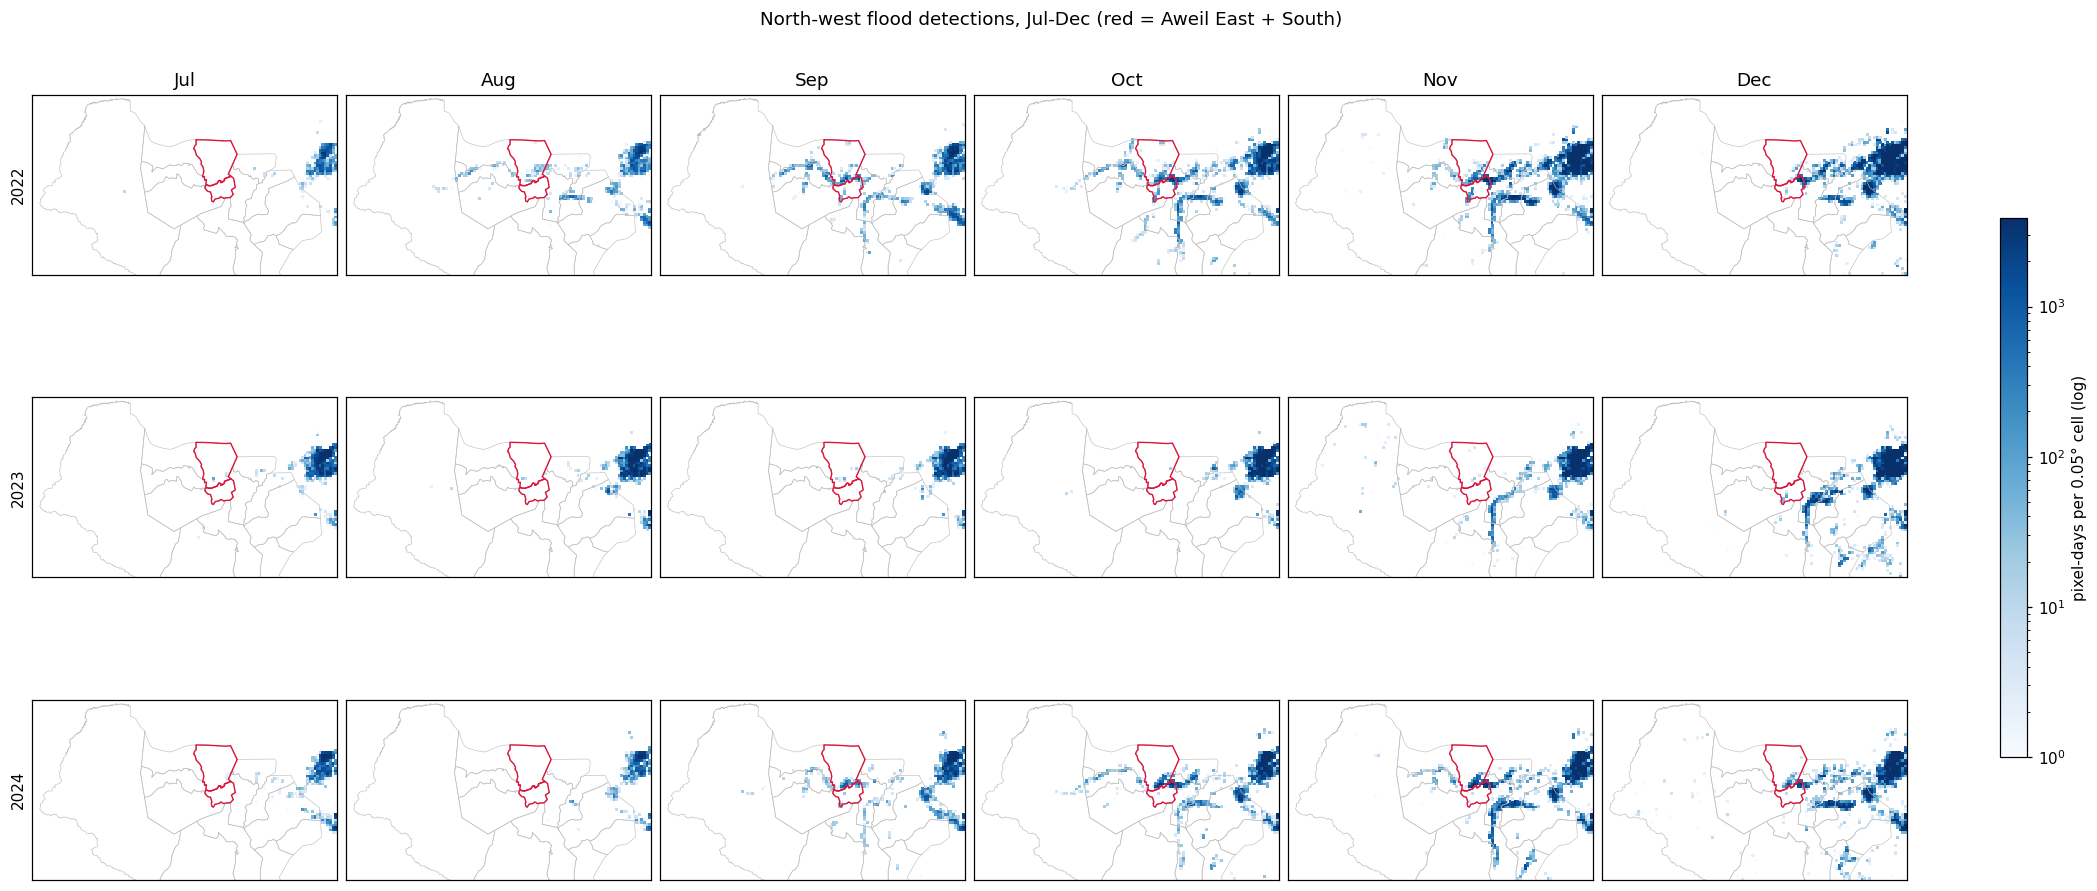

In [9]:
# 10. Is the flood label trustworthy? The near-empty 2023 season, and the rain link under other severity measures
aud = pd.read_csv(CACHE / "flood_file_audit_clean.csv")
aud["rows"] = aud.filter(regex="^rows_(recurring|unusual)$").sum(axis=1)
tile_rows = aud[aud.tile == "h20v08"].set_index("year").rows  # Aweil lies in tile h20v08
print("tile h20v08 (contains Aweil): flood rows inside South Sudan per year, millions")
print((tile_rows.loc[2018:2025] / 1e6).round(2).to_dict())
print(f"Aweil E+S Sep-Dec pixel-days: 2022 {fl.aweil_px[2022]:,}  2023 {fl.aweil_px[2023]:,}  2024 {fl.aweil_px[2024]:,}")
print("Aweil rain (mm):")
print(feat.loc[2020:2024, ["annual", "Jun-Aug", "Jul-Aug", "JJA anom vs trend"]].round(0).to_string())

# monthly maps of the wider north-west, Jul-Dec, for 2022 / 2023 / 2024
NW = dict(lon=(24.0, 30.0), lat=(7.0, 10.5))
co = 0.05
nw = ssd[ssd.cell_lon.between(*NW["lon"]) & ssd.cell_lat.between(*NW["lat"]) & ssd.year.isin([2022, 2023, 2024])
         & ssd.month.between(7, 12)].copy()
nw["clat"] = (np.floor(nw.cell_lat / co) * co + co / 2).round(3)
nw["clon"] = (np.floor(nw.cell_lon / co) * co + co / 2).round(3)
agg = nw.groupby(["year", "month", "clat", "clon"]).pixeldays.sum().reset_index()
norm = mcolors.LogNorm(vmin=1, vmax=np.percentile(agg.pixeldays[agg.clon < 29], 99))  # scale set by the NW, not the Sudd edge
fig, axs = plt.subplots(3, 6, figsize=(19, 8.5), sharex=True, sharey=True, layout="constrained")
outline = a2[a2.adm1_name.isin(["Northern Bahr el Ghazal", "Western Bahr el Ghazal", "Warrap"])]
for i, yr in enumerate([2022, 2023, 2024]):
    for j, m in enumerate(range(7, 13)):
        ax = axs[i, j]
        d = agg[(agg.year == yr) & (agg.month == m)]
        outline.boundary.plot(ax=ax, color="0.75", lw=0.4)
        a2[a2.adm2_name.isin(AWEIL_CORE)].boundary.plot(ax=ax, color="crimson", lw=0.9)
        sc = ax.scatter(d.clon, d.clat, c=d.pixeldays, s=4, cmap="Blues", norm=norm, marker="s", lw=0)
        ax.set_xlim(*NW["lon"]); ax.set_ylim(*NW["lat"]); ax.set_xticks([]); ax.set_yticks([])
        if i == 0: ax.set_title(months[m - 1])
        if j == 0: ax.set_ylabel(yr)
fig.colorbar(sc, ax=axs, shrink=0.6, label="pixel-days per 0.05° cell (log)")
fig.suptitle("North-west flood detections, Jul-Dec (red = Aweil East + South)")
fig.savefig(FIG / "10_northwest_monthly_2022_2024.png", bbox_inches="tight")

# does the rain link survive other ways of measuring severity?
E = df.loc[2003:2024]
xj = E["Jun-Aug"]
alts = {
    "main: log share, 2003-24": (E.index, E.log_share),
    "main, without 2023": (E.index[E.index != 2023], E.log_share.drop(2023)),
    "main, without 4 driest-flood years": (E.index[~E.index.isin([2004, 2015, 2016, 2023])],
                                           E.log_share.drop([2004, 2015, 2016, 2023])),
    "raw log km2-days, 2003-18 (one sensor era)": (E.loc[2003:2018].index, np.log(fl.km2_days.loc[2003:2018])),
    "raw log km2-days, 2003-24": (E.index, np.log(fl.km2_days.loc[2003:2024])),
}
rows = []
for name, (idx, yv) in alts.items():
    xv, yv = detrend(xj.loc[idx]), detrend(yv)
    pr, sr = stats.pearsonr(xv, yv), stats.spearmanr(xv, yv)
    rows.append({"severity measure": name, "n": len(idx), "detrended r": pr[0], "p": pr[1], "rho": sr[0], "rho p": sr[1]})
robust10 = pd.DataFrame(rows).set_index("severity measure")
print("\ndetrended Jun-Aug rain vs severity, under different severity measures:")
display(robust10.round(2))
km_top = fl.loc[2003:2024, "km2_days"]
km_sev = set(km_top.index[np.log(km_top) - np.polyval(np.polyfit(km_top.index, np.log(km_top), 1), km_top.index)
                          >= (np.log(km_top) - np.polyval(np.polyfit(km_top.index, np.log(km_top), 1), km_top.index)).quantile(2 / 3)])
main_sev = set(fl.index[fl.severe == 1])
print(f"severe seasons, main label: {sorted(main_sev)}")
print(f"severe seasons, detrended raw km2-days: {sorted(km_sev)}  -> overlap {len(main_sev & km_sev)} of {len(main_sev)}")

detrended r                       p                 partial r | local                
window                              Jul-Aug Jun-Aug May-Jul Jul-Aug Jun-Aug May-Jul           Jul-Aug Jun-Aug May-Jul
region                                                                                                               
local: Aweil E+S                       0.62    0.57    0.29    0.00    0.01    0.19               NaN     NaN     NaN
Lol middle: Aweil W+Centre             0.63    0.54    0.16    0.00    0.01    0.49              0.19    0.10   -0.21
Lol headwaters: Raja                   0.45    0.34   -0.10    0.03    0.12    0.66             -0.10   -0.21   -0.43
Jur/Pongo: Wau + Jur River             0.51    0.33    0.17    0.02    0.14    0.44             -0.16   -0.26   -0.08
Bahr el Arab source (Sudan/CAR)        0.44    0.29   -0.05    0.04    0.19    0.82              0.08   -0.06   -0.30
all upstream                           0.53    0.40   -0.01    0.01    0.06    0.96             -0.01   -0.19   -0.38

r of each region's Jun-Aug rain with local Aweil rain: {'local: Aweil E+S': 1.0, 'Lol middle: Aweil W+Centre': 0.88, 'Lol headwaters: Raja': 0.78, 'Jur/Pongo: Wau + Jur River': 0.8, 'Bahr el Arab source (Sudan/CAR)': 0.58, 'all upstream': 0.85}


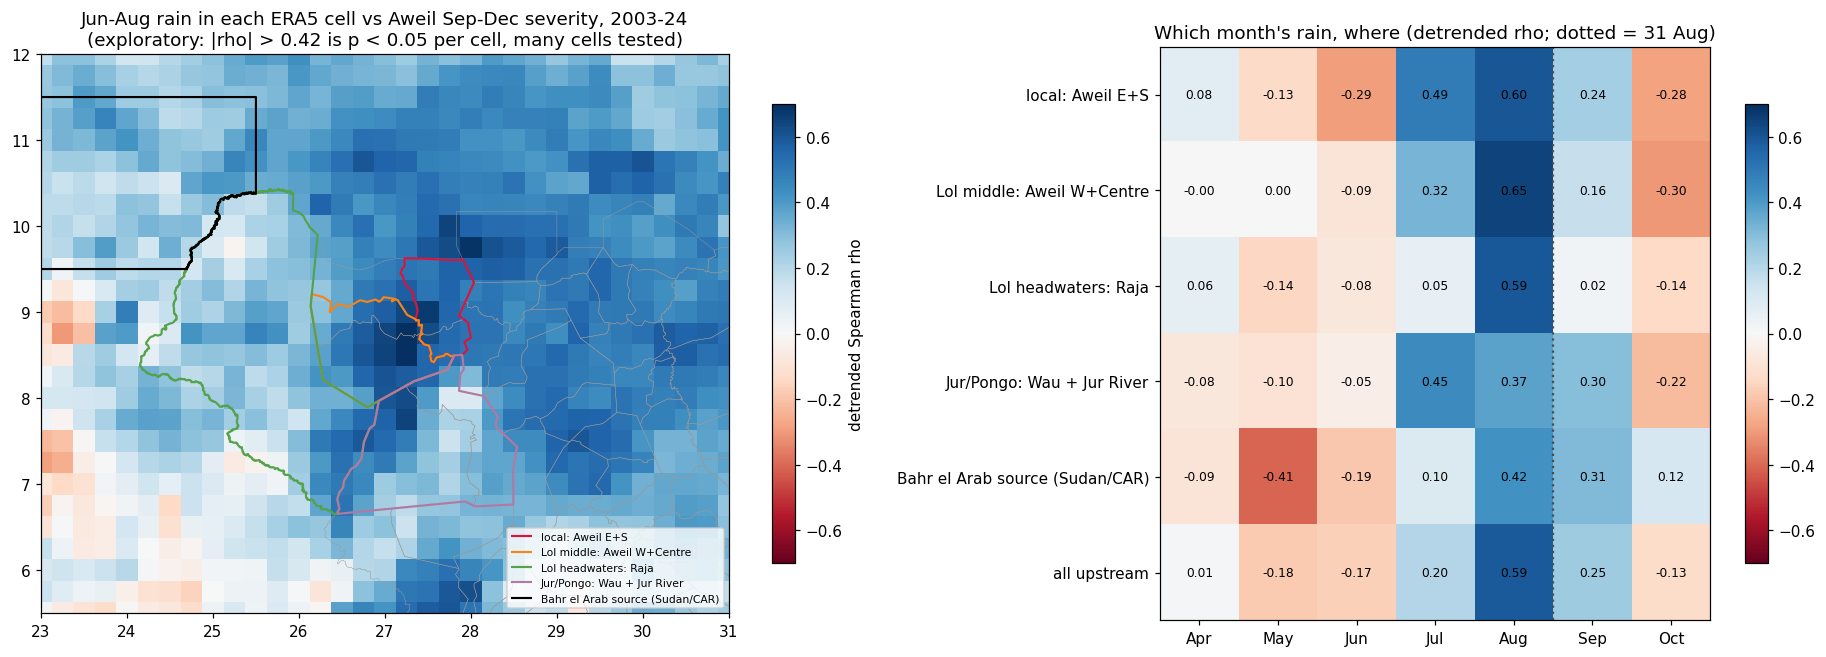

In [10]:
# 11. Upstream rain: does rain over the areas draining into Aweil explain its flooding better than local rain?
# Regions fixed from geography BEFORE looking at results (no catchment polygons in the repo; approximate):
#   Lol middle course   - Aweil West + Aweil Centre (Lol passes Nyamlell and Aweil town)
#   Lol headwaters      - Raja (Western Bahr el Ghazal)
#   Jur / Pongo side    - Wau + Jur River (Congo-Nile divide, south-west of Aweil)
#   Bahr el Arab source - 23-25.5E, 9.5-11.5N outside South Sudan (south Darfur / CAR border)
ssd0 = shapely.union_all(a2.geometry.values)
UP = {
    "local: Aweil E+S": geom(AWEIL_CORE),
    "Lol middle: Aweil W+Centre": geom(["Aweil West", "Aweil Centre"]),
    "Lol headwaters: Raja": geom(["Raja"]),
    "Jur/Pongo: Wau + Jur River": geom(["Wau", "Jur River"]),
    "Bahr el Arab source (Sudan/CAR)": shapely.box(23.0, 9.5, 25.5, 11.5).difference(ssd0),
}
UP["all upstream"] = shapely.union_all([g for k, g in UP.items() if not k.startswith("local")])

up_ym = {}
for k, g in UP.items():
    r = region_mean(era.tp, g, 0.25)
    up_ym[k] = r.groupby([r.index.year, r.index.month]).sum().unstack()
WIN = {"May-Jul": [5, 6, 7], "Jun-Aug": [6, 7, 8], "Jul-Aug": [7, 8]}
up_feat = pd.DataFrame({(k, w): t.loc[:, ms].sum(axis=1) for k, t in up_ym.items() for w, ms in WIN.items()})

E = fl.loc[2003:2024]
yv = detrend(E.log_share)
rows = []
for (k, w), x in up_feat.loc[2003:2024].items():
    xv = detrend(x)
    loc = detrend(up_feat.loc[2003:2024, ("local: Aweil E+S", w)])
    # partial r: upstream rain vs severity after removing what local rain (same window) explains
    res = lambda v: v - np.polyval(np.polyfit(loc, v, 1), loc)
    rows.append({"region": k, "window": w, "mean (mm)": x.mean(),
                 "r with local rain": stats.pearsonr(xv, loc)[0],
                 "detrended r": stats.pearsonr(xv, yv)[0], "p": stats.pearsonr(xv, yv)[1],
                 "rho": stats.spearmanr(xv, yv)[0],
                 "partial r | local": np.nan if k.startswith("local") else stats.pearsonr(res(xv), res(yv))[0]})
up11 = pd.DataFrame(rows)
display(up11.pivot(index="region", columns="window", values=["detrended r", "p", "partial r | local"])
        .reindex(list(UP)).round(2))
print("r of each region's Jun-Aug rain with local Aweil rain:",
      up11[up11.window == "Jun-Aug"].set_index("region")["r with local rain"].round(2).to_dict())

# which month's rain, where? detrended Spearman of each month's rain with Sep-Dec severity
heat = pd.DataFrame({k: {months[m - 1]: stats.spearmanr(detrend(t.loc[2003:2024, m]), yv)[0] for m in range(4, 11)}
                     for k, t in up_ym.items()}).T

# exploratory cross-check: the same correlation for every ERA5 cell (Jun-Aug rain, 2003-24)
jja_cells = era.tp.sel(time=era.time.dt.month.isin([6, 7, 8])).groupby("time.year").sum().sel(year=slice(2003, 2024))
Y = jja_cells.values.reshape(len(jja_cells.year), -1)
t_ = jja_cells.year.values.astype(float)
Yd = Y - (np.outer(t_, np.polyfit(t_, Y, 1)[0]) + np.polyfit(t_, Y, 1)[1])
Yr = stats.rankdata(Yd, axis=0); sr_ = stats.rankdata(yv.values)
cmap_r = np.array([stats.pearsonr(Yr[:, i], sr_)[0] for i in range(Yr.shape[1])]).reshape(jja_cells.shape[1:])

fig, axs = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [1.25, 1]})
im = axs[0].pcolormesh(era.longitude, era.latitude, cmap_r, cmap="RdBu", vmin=-0.7, vmax=0.7, shading="nearest")
a2.boundary.plot(ax=axs[0], color="0.6", lw=0.3)
for (k, g), col in zip(UP.items(), ["crimson", "#f58518", "#54a24b", "#b279a2", "k"]):
    gpd.GeoSeries([g], crs=4326).boundary.plot(ax=axs[0], color=col, lw=1.4, label=k)
axs[0].legend(fontsize=7, loc="lower right"); axs[0].set_xlim(23, 31); axs[0].set_ylim(5.5, 12); axs[0].set_aspect("equal")
fig.colorbar(im, ax=axs[0], label="detrended Spearman rho", shrink=0.8)
axs[0].set_title("Jun-Aug rain in each ERA5 cell vs Aweil Sep-Dec severity, 2003-24\n(exploratory: |rho| > 0.42 is p < 0.05 per cell, many cells tested)")
im = axs[1].imshow(heat.values, cmap="RdBu", vmin=-0.7, vmax=0.7, aspect="auto")
axs[1].set_xticks(range(heat.shape[1]), heat.columns); axs[1].set_yticks(range(len(heat)), heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        axs[1].text(j, i, f"{heat.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
axs[1].axvline(4.5, color="0.3", ls=":"); axs[1].set_title("Which month's rain, where (detrended rho; dotted = 31 Aug)")
fig.colorbar(im, ax=axs[1], shrink=0.8)
fig.tight_layout(); fig.savefig(FIG / "11_upstream_rain.png", bbox_inches="tight")

,linear: LOO skill vs trend-only,logistic: Brier skill vs climatology
rain feature,,
local: Aweil E+S | May-Jul,-0.006,-0.083
local: Aweil E+S | Jun-Aug,0.227,-0.063
local: Aweil E+S | Jul-Aug,0.262,-0.026
Lol middle: Aweil W+Centre | May-Jul,-0.032,-0.068
Lol middle: Aweil W+Centre | Jun-Aug,0.185,-0.057
Lol middle: Aweil W+Centre | Jul-Aug,0.243,-0.018
Lol headwaters: Raja | May-Jul,-0.025,-0.033
Lol headwaters: Raja | Jun-Aug,0.078,-0.038
Lol headwaters: Raja | Jul-Aug,0.050,0.017


picked in the folds: {'Lol middle: Aweil W+Centre | Jul-Aug': 20, 'local: Aweil E+S | Jul-Aug': 2}
skill > 0 means better than the baseline out of sample; the per-feature rows are 18 tries on 22 seasons, so the best of them is optimistic - the in-fold row is the fair number.
  local: Aweil E+S | Jun-Aug: +100 mm Jun-Aug rain -> severity x4.2 (95% CI x1.5-x11.6, p = 0.007), in-sample R2 = 0.40
      all upstream | Jun-Aug: +100 mm Jun-Aug rain -> severity x4.4 (95% CI x0.9-x22.9, p = 0.072), in-sample R2 = 0.25


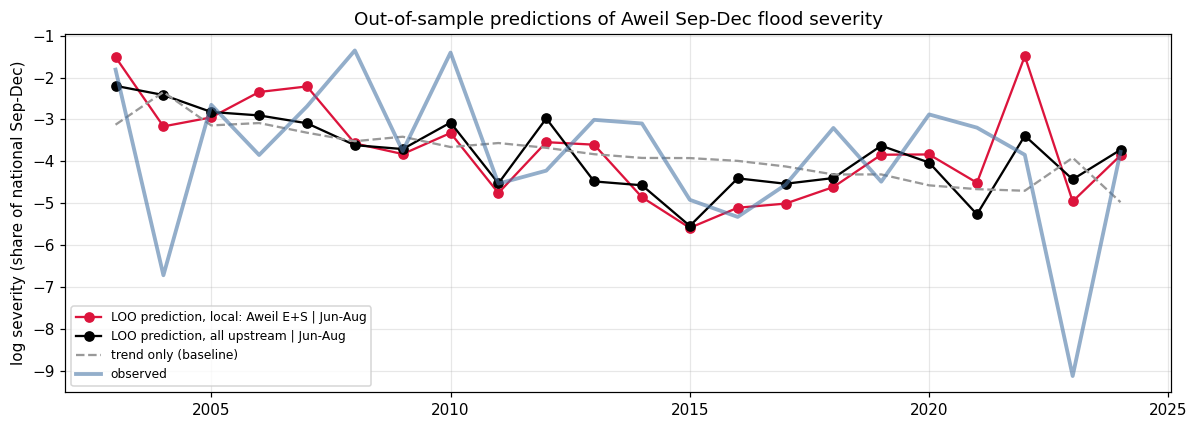

In [11]:
# 12. Out-of-sample test, local vs upstream rain (2003-24, leave one season out)
#   (a) linear: log severity ~ year + rain  (year term = in-fold detrending; ZOA prefers linear models)
#   (b) logistic: severe ~ rain detrended in-fold (as in cell 9)
#   (c) honest selection: the region/window is chosen inside each fold from the training seasons only
E = fl.loc[2003:2024].copy()
yrs12 = E.index.values.astype(float)
ys, yb = E.log_share.values, E.severe.values.astype(int)
cands = {f"{k} | {w}": up_feat.loc[2003:2024, (k, w)].values for k, w in up_feat.columns}
n = len(E)


def ols_pred(Xtr, ytr, Xte):
    A = np.column_stack([np.ones(len(Xtr)), Xtr]); B = np.column_stack([np.ones(len(Xte)), Xte])
    return B @ np.linalg.lstsq(A, ytr, rcond=None)[0]


def detr(x, tr):
    return x - np.polyval(np.polyfit(yrs12[tr], x[tr], 1), yrs12)


def pick(tr):
    """Candidate with the highest training-season |r| between in-fold-detrended rain and log severity."""
    return max(cands, key=lambda c: abs(np.corrcoef(detr(cands[c], tr)[tr], detr(ys, tr)[tr])[0, 1]))


base_lin = np.empty(n); clim_b = np.empty(n)
lin = {c: np.empty(n) for c in cands}; logi = {c: np.empty(n) for c in cands}
sel_lin, sel_log, chosen = np.empty(n), np.empty(n), []
for i in range(n):
    tr = np.arange(n) != i
    base_lin[i] = ols_pred(yrs12[tr], ys[tr], yrs12[i:i + 1])[0]
    clim_b[i] = yb[tr].mean()
    for c, x in cands.items():
        X = np.column_stack([yrs12, x])
        lin[c][i] = ols_pred(X[tr], ys[tr], X[i:i + 1])[0]
        xd = detr(x, tr); z = (xd - xd[tr].mean()) / xd[tr].std()
        logi[c][i] = LogisticRegression(C=1.0).fit(z[tr, None], yb[tr]).predict_proba(z[i:i + 1, None])[0, 1]
    c = pick(tr); chosen.append(c)
    sel_lin[i], sel_log[i] = lin[c][i], logi[c][i]

sse = lambda p: ((ys - p) ** 2).sum()
bs_c = brier_score_loss(yb, clim_b)
rows = []
for c in cands:
    rows.append({"rain feature": c, "linear: LOO skill vs trend-only": 1 - sse(lin[c]) / sse(base_lin),
                 "logistic: Brier skill vs climatology": 1 - brier_score_loss(yb, logi[c]) / bs_c})
rows.append({"rain feature": "SELECTED IN-FOLD (honest)", "linear: LOO skill vs trend-only": 1 - sse(sel_lin) / sse(base_lin),
             "logistic: Brier skill vs climatology": 1 - brier_score_loss(yb, sel_log) / bs_c})
res12 = pd.DataFrame(rows).set_index("rain feature")
display(res12.round(3))
print("picked in the folds:", pd.Series(chosen).value_counts().to_dict())
print("skill > 0 means better than the baseline out of sample; the per-feature rows are 18 tries on 22 seasons,"
      " so the best of them is optimistic - the in-fold row is the fair number.")

# the pre-registered comparison: local vs all-upstream, Jun-Aug
for c in ["local: Aweil E+S | Jun-Aug", "all upstream | Jun-Aug"]:
    X = sm.add_constant(np.column_stack([yrs12 - yrs12.mean(), cands[c]]))
    m = sm.OLS(ys, X).fit()
    print(f"{c:>28}: +100 mm Jun-Aug rain -> severity x{np.exp(m.params[2] * 100):.1f} "
          f"(95% CI x{np.exp(m.conf_int()[2][0] * 100):.1f}-x{np.exp(m.conf_int()[2][1] * 100):.1f}, p = {m.pvalues[2]:.3f}), "
          f"in-sample R2 = {m.rsquared:.2f}")

fig, ax = plt.subplots(figsize=(11, 4))
for c, col in [("local: Aweil E+S | Jun-Aug", "crimson"), ("all upstream | Jun-Aug", "k")]:
    ax.plot(E.index, lin[c], marker="o", color=col, label=f"LOO prediction, {c}")
ax.plot(E.index, base_lin, color="0.6", ls="--", label="trend only (baseline)")
ax.plot(E.index, ys, color="#4c78a8", lw=2.5, alpha=0.6, label="observed")
ax.set_ylabel("log severity (share of national Sep-Dec)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title("Out-of-sample predictions of Aweil Sep-Dec flood severity")
fig.tight_layout(); fig.savefig(FIG / "12_local_vs_upstream_loo.png", bbox_inches="tight")

strongest lag per region (months):


,lag,rho,p,partial rho | local,partial p
region,,,,,
local: Aweil E+S,4.0,0.349,0.002,NaN,NaN
Lol middle: Aweil W+Centre,4.0,0.316,0.002,0.007,0.952
Lol headwaters: Raja,2.0,0.195,0.070,0.032,0.742
Jur/Pongo: Wau + Jur River,4.0,0.291,0.003,0.013,0.905
Bahr el Arab source (Sudan/CAR),2.0,0.292,0.005,0.133,0.217
all upstream,2.0,0.267,0.008,0.088,0.412


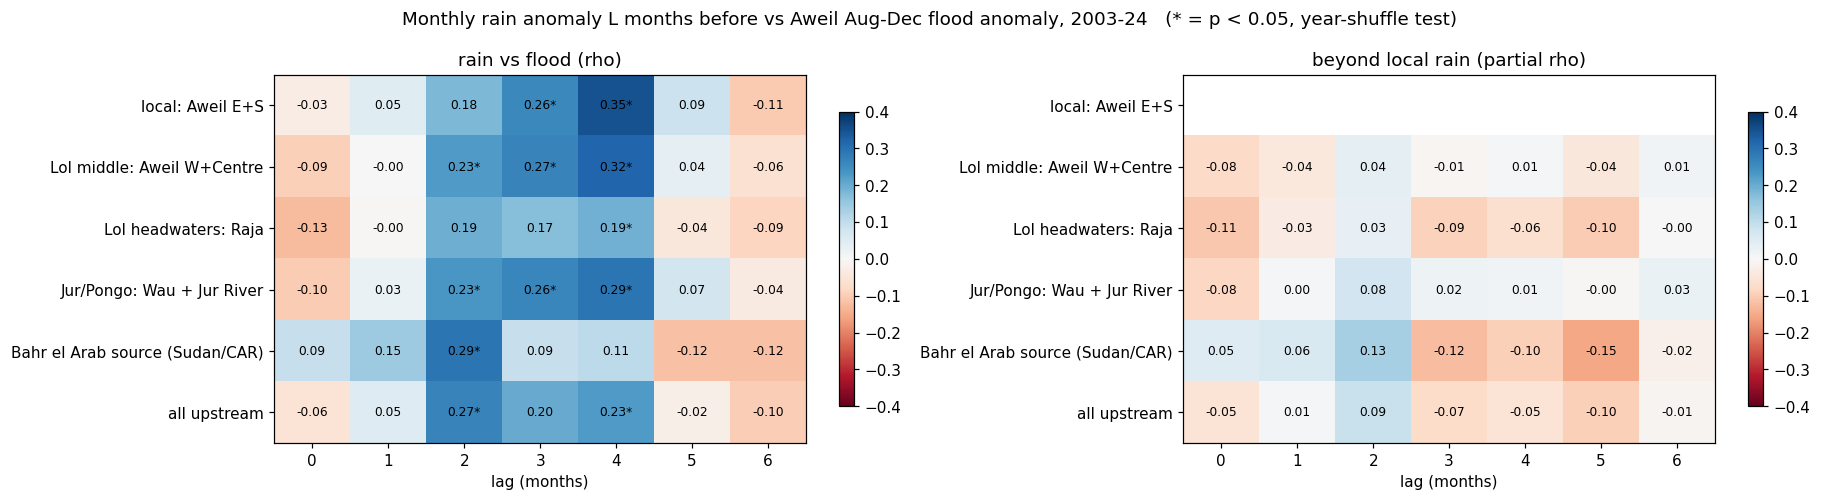

In [12]:
# 13. Time lags, monthly: does upstream rain line up with Aweil's flooding at a LONGER lag than local rain?
# Anomalies: each calendar month is detrended across 2003-24 (removes the seasonal cycle and the drying/sensor drift).
# Target: Aweil's monthly flood share (log) in Aug-Dec. Rain: that region's rain L months earlier.
# Significance: whole years are shuffled (keeps the within-season autocorrelation), so p-values are honest.


def lag_scan(rain_anoms, flood_anom, targets, lags, col_at_lag, local, n_perm=1000, seed=0):
    """Spearman of rain at lag L vs flood, per region and lag; partial version after removing local rain at all lags.

    rain_anoms: {region: DataFrame years x steps}; flood_anom: DataFrame years x steps;
    col_at_lag(c, L) gives the rain column that sits L steps before flood column c."""
    rk = lambda a: stats.rankdata(a.ravel()).reshape(a.shape)
    F = rk(flood_anom[targets].values)
    R = {k: {L: rk(np.column_stack([ra[col_at_lag(c, L)].values for c in targets])) for L in lags}
         for k, ra in rain_anoms.items()}
    D = np.column_stack([np.ones(F.size)] + [R[local][L].ravel() for L in lags])
    F_res = F.ravel() - D @ np.linalg.lstsq(D, F.ravel(), rcond=None)[0]  # flood not explained by local rain
    corr = lambda a, b: np.corrcoef(a, b)[0, 1]
    rng = np.random.default_rng(seed)
    perms = [rng.permutation(F.shape[0]) for _ in range(n_perm)]
    out = {}
    for k in rain_anoms:
        for L in lags:
            x = R[k][L]
            rho, prt = corr(x.ravel(), F.ravel()), corr(x.ravel(), F_res)
            null = np.array([corr(x[p].ravel(), F.ravel()) for p in perms])
            null_p = np.array([corr(x[p].ravel(), F_res) for p in perms])
            out[(k, L)] = {"rho": rho, "p": (np.sum(np.abs(null) >= abs(rho)) + 1) / (n_perm + 1),
                           "partial rho | local": np.nan if k == local else prt,
                           "partial p": np.nan if k == local else (np.sum(np.abs(null_p) >= abs(prt)) + 1) / (n_perm + 1)}
    return pd.DataFrame(out).T.rename_axis(["region", "lag"])


def plot_lag_scan(res, unit, fname, title):
    fig, axs = plt.subplots(1, 2, figsize=(17, 4.6))
    for ax, val, pcol, ttl in [(axs[0], "rho", "p", "rain vs flood (rho)"),
                               (axs[1], "partial rho | local", "partial p", "beyond local rain (partial rho)")]:
        t, p = res[val].unstack().reindex(list(UP)), res[pcol].unstack().reindex(list(UP))
        im = ax.imshow(t.values.astype(float), cmap="RdBu", vmin=-0.4, vmax=0.4, aspect="auto")
        for i in range(t.shape[0]):
            for j in range(t.shape[1]):
                v = t.values[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f"{v:.2f}" + ("*" if p.values[i, j] < 0.05 else ""), ha="center", va="center",
                            fontsize=7 if t.shape[1] > 8 else 8)
        ax.set_xticks(range(t.shape[1]), t.columns); ax.set_yticks(range(t.shape[0]), t.index)
        ax.set_xlabel(f"lag ({unit})"); ax.set_title(ttl); fig.colorbar(im, ax=ax, shrink=0.8)
    fig.suptitle(title + "   (* = p < 0.05, year-shuffle test)")
    fig.tight_layout(); fig.savefig(FIG / fname, bbox_inches="tight")


FLOOD_MONTHS = [8, 9, 10, 11, 12]
LAGS_M = list(range(0, 7))
lsh_m = np.log((fm / nat_m.unstack()).loc[2003:2024].fillna(0) + 1e-4)
flood_anom_m = lsh_m.apply(detrend)
rain_anom_m = {k: t.loc[2003:2024].apply(detrend) for k, t in up_ym.items()}
lag_m = lag_scan(rain_anom_m, flood_anom_m, FLOOD_MONTHS, LAGS_M, lambda c, L: c - L, local="local: Aweil E+S")

peak_m = lag_m.reset_index().loc[lambda d: d.groupby("region").rho.idxmax()].set_index("region").reindex(list(UP))
print("strongest lag per region (months):")
display(peak_m[["lag", "rho", "p", "partial rho | local", "partial p"]].astype(float).round(3))
plot_lag_scan(lag_m, "months", "13_lag_scan_monthly.png",
              "Monthly rain anomaly L months before vs Aweil Aug-Dec flood anomaly, 2003-24")


daily rebuild vs monthly table: Aweil differs by 0.00%, national by 0.01%


strongest lag per region (weeks; rain = 4-week total ending that many weeks before the flood week):


,lag,rho,p,partial rho | local,partial p
region,,,,,
local: Aweil E+S,9.0,0.280,0.002,NaN,NaN
Lol middle: Aweil W+Centre,9.0,0.279,0.002,0.001,0.994
Lol headwaters: Raja,9.0,0.235,0.002,-0.004,0.966
Jur/Pongo: Wau + Jur River,9.0,0.293,0.002,0.042,0.611
Bahr el Arab source (Sudan/CAR),8.0,0.274,0.002,0.089,0.259
all upstream,9.0,0.299,0.002,0.034,0.701


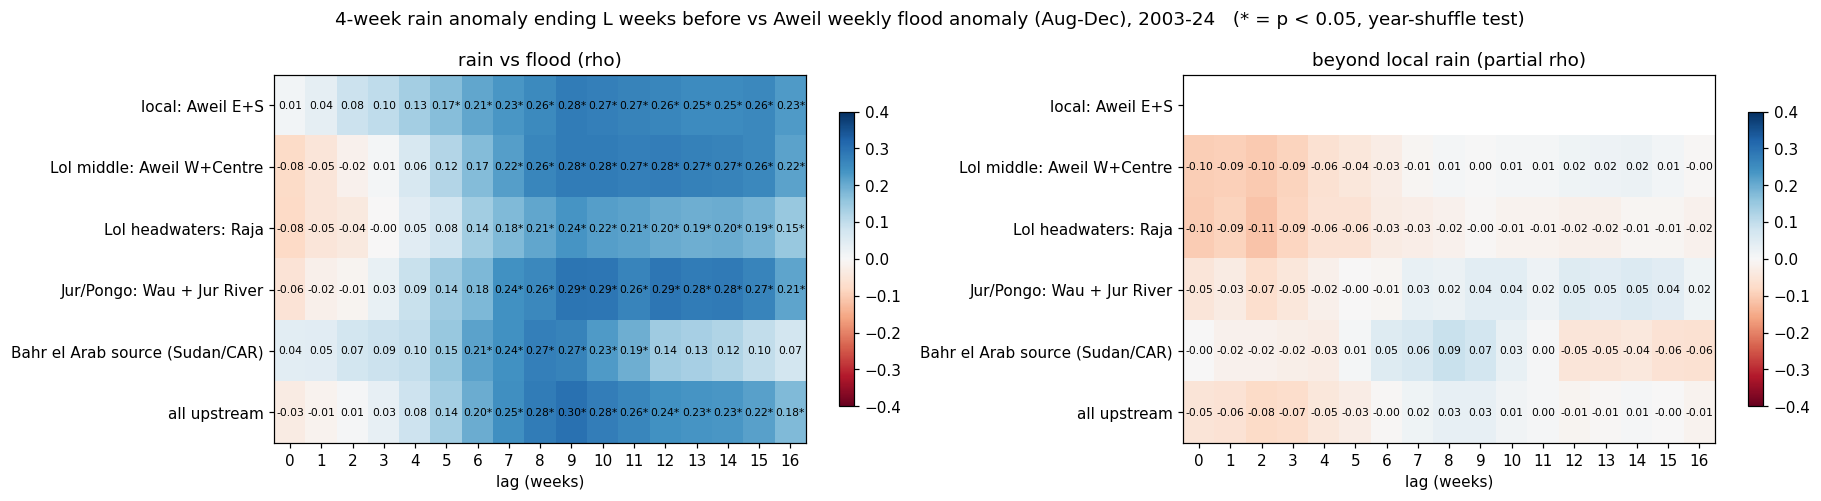

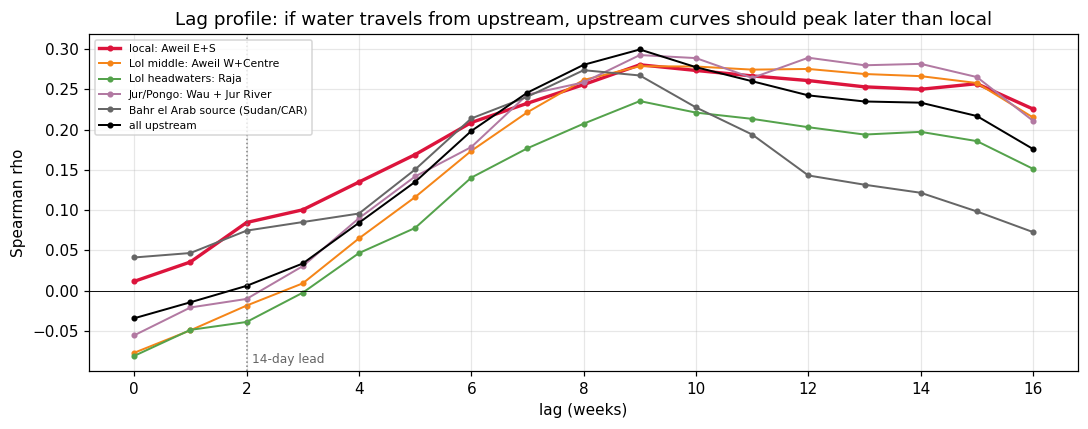

In [13]:
# 14. Time lags, weekly: daily flood dates rebuilt from the raw masks (the cleaned files lost their dates),
# so travel times of 1-4 weeks become visible. Rain = 4-week total ending L weeks before the flood week.
DAILY = CACHE / "flood_daily_aweil_national.parquet"
if not DAILY.exists():
    lut_c = lut.assign(aweil=lut.adm2_name.isin(AWEIL_CORE))[["cell_lat", "cell_lon", "aweil"]]
    out = []
    for year in xc.YEARS:
        frames = [pd.read_parquet(src, columns=["date", "lat", "lon"])
                  for tile in xc.TILES for kind in ("compact_recurring", "compact_unusual")
                  if (src := REPO / "raw_data/flood_masks" / kind / f"flood_events_{tile}_{year}.parquet").exists()]
        ev = pd.concat(frames, ignore_index=True)
        ev["date"] = pd.to_datetime(ev.date.astype(str), errors="coerce")
        ev = ev.dropna().drop_duplicates(["date", "lat", "lon"])  # the flood cleaning steps of data_cleaning.py
        ev["cell_lat"] = (np.floor(ev.lat / xc.CELL) * xc.CELL + xc.CELL / 2).round(3).astype("float32")
        ev["cell_lon"] = (np.floor(ev.lon / xc.CELL) * xc.CELL + xc.CELL / 2).round(3).astype("float32")
        ev = ev.merge(lut_c, on=["cell_lat", "cell_lon"], how="inner")  # inside South Sudan
        g = ev.groupby(["date", "aweil"]).size().unstack(fill_value=0).reindex(columns=[False, True], fill_value=0)
        out.append(pd.DataFrame({"national": g.sum(axis=1), "aweil": g[True]}))
        print(year, end=" ", flush=True)
    pd.concat(out).rename_axis("date").reset_index().to_parquet(DAILY, index=False)
daily = pd.read_parquet(DAILY).set_index("date")

# check: the daily rebuild must reproduce the monthly table used in cells 6-13
chk = daily.groupby([daily.index.year, daily.index.month]).sum()
chk.index.names = ["year", "month"]
dev_a = (chk.aweil.reindex(YM, fill_value=0) - flood_monthly(AWEIL_CORE)).abs().sum() / flood_monthly(AWEIL_CORE).sum()
dev_n = (chk.national.reindex(YM, fill_value=0) - nat_m).abs().sum() / nat_m.sum()
print(f"\ndaily rebuild vs monthly table: Aweil differs by {dev_a:.2%}, national by {dev_n:.2%}")

# 7-day weeks counted from 1 Jan (week 0-51; the last 1-2 days of a year are dropped)
wk = lambda idx: (idx.dayofyear - 1) // 7
daily = daily[wk(daily.index) < 52]
fw = daily.groupby([daily.index.year, wk(daily.index)]).sum()
fw.index.names = ["year", "week"]
fw = fw.reindex(pd.MultiIndex.from_product([xc.YEARS, range(52)], names=["year", "week"]), fill_value=0)
lsh_w = np.log((fw.aweil + 1) / (fw.national + 1)).unstack().loc[2003:2024]
flood_anom_w = lsh_w.apply(detrend)

up_daily = {k: region_mean(era.tp, g, 0.25) for k, g in UP.items()}
rain_anom_w = {}
for k, r in up_daily.items():
    r = r[wk(r.index) < 52]
    w = r.groupby([r.index.year, wk(r.index)]).sum().unstack()  # years x weeks
    acc = w.T.rolling(4, min_periods=4).sum().T  # 4-week total ending in that week (first weeks of a year: NaN)
    rain_anom_w[k] = acc.loc[2003:2024].apply(lambda s: detrend(s) if s.notna().all() else s)

FLOOD_WEEKS = list(range(30, 52))  # ~ 23 Jul - 23 Dec, Aweil's flood season
LAGS_W = list(range(0, 17))
lag_w = lag_scan(rain_anom_w, flood_anom_w, FLOOD_WEEKS, LAGS_W, lambda c, L: c - L, local="local: Aweil E+S", n_perm=500)

peak_w = lag_w.reset_index().loc[lambda d: d.groupby("region").rho.idxmax()].set_index("region").reindex(list(UP))
print("strongest lag per region (weeks; rain = 4-week total ending that many weeks before the flood week):")
display(peak_w[["lag", "rho", "p", "partial rho | local", "partial p"]].astype(float).round(3))
plot_lag_scan(lag_w, "weeks", "14_lag_scan_weekly.png",
              "4-week rain anomaly ending L weeks before vs Aweil weekly flood anomaly (Aug-Dec), 2003-24")

fig, ax = plt.subplots(figsize=(10, 4))
for (k, col) in zip(UP, ["crimson", "#f58518", "#54a24b", "#b279a2", "0.4", "k"]):
    ax.plot(LAGS_W, lag_w.loc[k, "rho"].astype(float), marker="o", ms=3, color=col, label=k, lw=2.2 if k.startswith("local") else 1.3)
ax.axhline(0, color="k", lw=0.6); ax.axvline(2, color="0.5", ls=":", lw=1); ax.text(2.1, ax.get_ylim()[0] * 0.9, "14-day lead", fontsize=8, color="0.4")
ax.set_xlabel("lag (weeks)"); ax.set_ylabel("Spearman rho"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax.set_title("Lag profile: if water travels from upstream, upstream curves should peak later than local")
fig.tight_layout(); fig.savefig(FIG / "14_lag_profile_weekly.png", bbox_inches="tight")